# 다변수 교호작용 EDA

`is_100` 외의 변수들끼리의 **교호작용(interaction)** 이  
`is_repurchase`, `is_churn_prevented` 에 미치는 영향을 분석합니다.

### 기본 교호작용
| # | 분석 | 설명 |
|---|------|------|
| 1 | gender × age_group | 성별 × 연령대 조합별 재구매/이탈방지율 |
| 2 | gender × payment_device | 성별 × 결제기기 |
| 3 | gender × max_screen | 성별 × 동시접속수 |
| 4 | age_group × payment_device | 연령대 × 결제기기 |
| 5 | age_group × max_screen | 연령대 × 동시접속수 |
| 6 | age_group × billing_method | 연령대 × 결제방식 |
| 7 | is_repurchase × gender | 재구매 여부 × 성별 → 이탈방지율 |
| 8 | is_repurchase × age_group | 재구매 여부 × 연령대 → 이탈방지율 |
| 9 | is_repurchase × payment_device | 재구매 여부 × 결제기기 → 이탈방지율 |

### 심화 교호작용
| # | 분석 | 설명 |
|---|------|------|
| 10 | reg_hour_group × gender | 가입시간대 × 성별 |
| 11 | reg_hour_group × age_group | 가입시간대 × 연령대 |
| 12 | product_code × gender | 상품코드 × 성별 |
| 13 | product_code × age_group | 상품코드 × 연령대 |
| 14 | billing_method × gender | 결제방식 × 성별 |
| 15 | billing_method × payment_device | 결제방식 × 결제기기 |
| 16 | is_churn_prevented × gender → 재구매율 | 이탈방지 × 성별 (역방향) |
| 17 | is_churn_prevented × age_group → 재구매율 | 이탈방지 × 연령대 (역방향) |
| 18 | is_churn_prevented × payment_device → 재구매율 | 이탈방지 × 결제기기 (역방향) |
| 19 | duration_group × gender | 구독기간 × 성별 |
| 20 | duration_group × age_group | 구독기간 × 연령대 |
| 21 | duration_group × is_100 | 구독기간 × 100원딜 |
| 22 | 3-way: is_100 × gender × age_group | 3변수 교호작용 |
| 23 | 3-way: is_100 × age_group × payment_device | 3변수 교호작용 |
| 24 | 종합 요약 | 전체 교호작용 효과 크기 비교 |

In [26]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

_BASE = Path('../data/02_interim/260504_promotion_split')
df = pd.concat([
    pd.read_csv(_BASE / 'promotion_0_membership_v2.csv', encoding='utf-8-sig'),
    pd.read_csv(_BASE / 'promotion_1_membership_v2.csv', encoding='utf-8-sig'),
], ignore_index=True)

df['is_100'] = (df['price'] == 100).astype(int)
df['price_label'] = df['is_100'].map({1: '100원', 0: '일반요금'})
df['age_group'] = pd.cut(df['age'], bins=[14, 19, 29, 39, 49, 70],
                         labels=['10대', '20대', '30대', '40대', '50대+'])
df['reg_hour_group'] = pd.cut(df['reg_hour'], bins=[-1, 5, 11, 17, 23],
                               labels=['새벽(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)'])
df['repurchase_label'] = df['is_repurchase'].map({0: '재구매 아님', 1: '재구매'})
df['churn_label']     = df['is_churn_prevented'].map({0: '이탈방지 아님', 1: '이탈방지'})
df['promotion_label'] = df['is_promotion'].map({0: '일반', 1: '프로모션'})

df['reg_date_dt']  = pd.to_datetime(df['reg_date'])
df['end_date_dt']  = pd.to_datetime(df['end_date'])
df['duration_days'] = (df['end_date_dt'] - df['reg_date_dt']).dt.days
df['duration_group'] = pd.cut(df['duration_days'],
                               bins=[-1, 29, 89, 364, 99999],
                               labels=['단기(<30일)', '중기(30-89일)', '장기(90-364일)', '초장기(1년+)'])

OUTCOMES = ['is_repurchase', 'is_churn_prevented']
OUTCOME_LABELS = {'is_repurchase': '재구매율(%)', 'is_churn_prevented': '이탈방지율(%)'}

_N_TOTAL = len(df)
_N_INFO  = f'전체 N={_N_TOTAL:,}명'

def two_var_heatmap(df, row_col, col_col, row_label, col_label, figsize=(18, 5)):
    n_total = len(df)
    cnt_pivot = df.groupby([row_col, col_col], observed=True).size().unstack(col_col).fillna(0).astype(int)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, outcome in zip(axes, OUTCOMES):
        pivot = df.groupby([row_col, col_col], observed=True)[outcome].mean().mul(100).unstack(col_col)
        annot = pivot.copy().astype(object)
        for r in pivot.index:
            for c in pivot.columns:
                val = pivot.loc[r, c]
                n = cnt_pivot.loc[r, c] if r in cnt_pivot.index and c in cnt_pivot.columns else 0
                annot.loc[r, c] = f'{val:.1f}%\n(n={n:,})' if not pd.isna(val) else ''
        sns.heatmap(pivot, annot=annot, fmt='', cmap='YlOrRd', ax=ax,
                    linewidths=0.5, cbar_kws={'label': '%'}, annot_kws={'size': 7})
        ax.set_title(f'{row_label} × {col_label} → {OUTCOME_LABELS[outcome]}')
        ax.set_xlabel(col_label)
        ax.set_ylabel(row_label)
    fig.suptitle(f'전체 N={n_total:,}명', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

def two_var_barplot(df, split_col, split_label, group_col, group_label, outcome, figsize=(18, 5)):
    categories = sorted(df[split_col].dropna().unique().astype(str))
    n = len(categories)
    n_total = len(df)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=True)
    if n == 1:
        axes = [axes]
    for ax, cat in zip(axes, categories):
        sub = df[df[split_col].astype(str) == cat]
        vals = sub.groupby(group_col, observed=True)[outcome].mean().mul(100).sort_values()
        n_per_cat = sub.groupby(group_col, observed=True).size()
        vals.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{split_label} = {cat}\n(n={len(sub):,}, {len(sub)/n_total*100:.1f}%)')
        ax.set_xlabel('%')
        for i, p in enumerate(ax.patches):
            w = p.get_width()
            cat_name = vals.index[i]
            n_bar = int(n_per_cat.get(cat_name, 0))
            ax.annotate(f'{w:.1f}%\n(n={n_bar:,})',
                        (w, p.get_y() + p.get_height()/2),
                        ha='left', va='center', fontsize=8)
    fig.suptitle(f'{split_label} × {group_label} → {OUTCOME_LABELS[outcome]}\n전체 N={n_total:,}명', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

def single_outcome_heatmap(df, row_col, col_col, row_label, col_label, outcome, figsize=(12, 5)):
    n_total = len(df)
    cnt_pivot = df.groupby([row_col, col_col], observed=True).size().unstack(col_col).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=figsize)
    pivot = df.groupby([row_col, col_col], observed=True)[outcome].mean().mul(100).unstack(col_col)
    annot = pivot.copy().astype(object)
    for r in pivot.index:
        for c in pivot.columns:
            val = pivot.loc[r, c]
            n = cnt_pivot.loc[r, c] if r in cnt_pivot.index and c in cnt_pivot.columns else 0
            annot.loc[r, c] = f'{val:.1f}%\n(n={n:,})' if not pd.isna(val) else ''
    sns.heatmap(pivot, annot=annot, fmt='', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': '%'}, annot_kws={'size': 7})
    ax.set_title(f'{row_label} × {col_label} → {OUTCOME_LABELS[outcome]}\n[전체 N={n_total:,}명]')
    ax.set_xlabel(col_label)
    ax.set_ylabel(row_label)
    plt.tight_layout()
    plt.show()

print('데이터 준비 완료')
print(f'전체 {len(df):,}건')
print(f'구독기간(일) 기술통계:\n{df["duration_days"].describe().round(1)}')

데이터 준비 완료
전체 14,873건
구독기간(일) 기술통계:
count    14873.0
mean        30.4
std          4.8
min          0.0
25%         31.0
50%         31.0
75%         31.0
max         32.0
Name: duration_days, dtype: float64


---
# 기본 교호작용 분석

---
## 1. gender × age_group (성별 × 연령대)

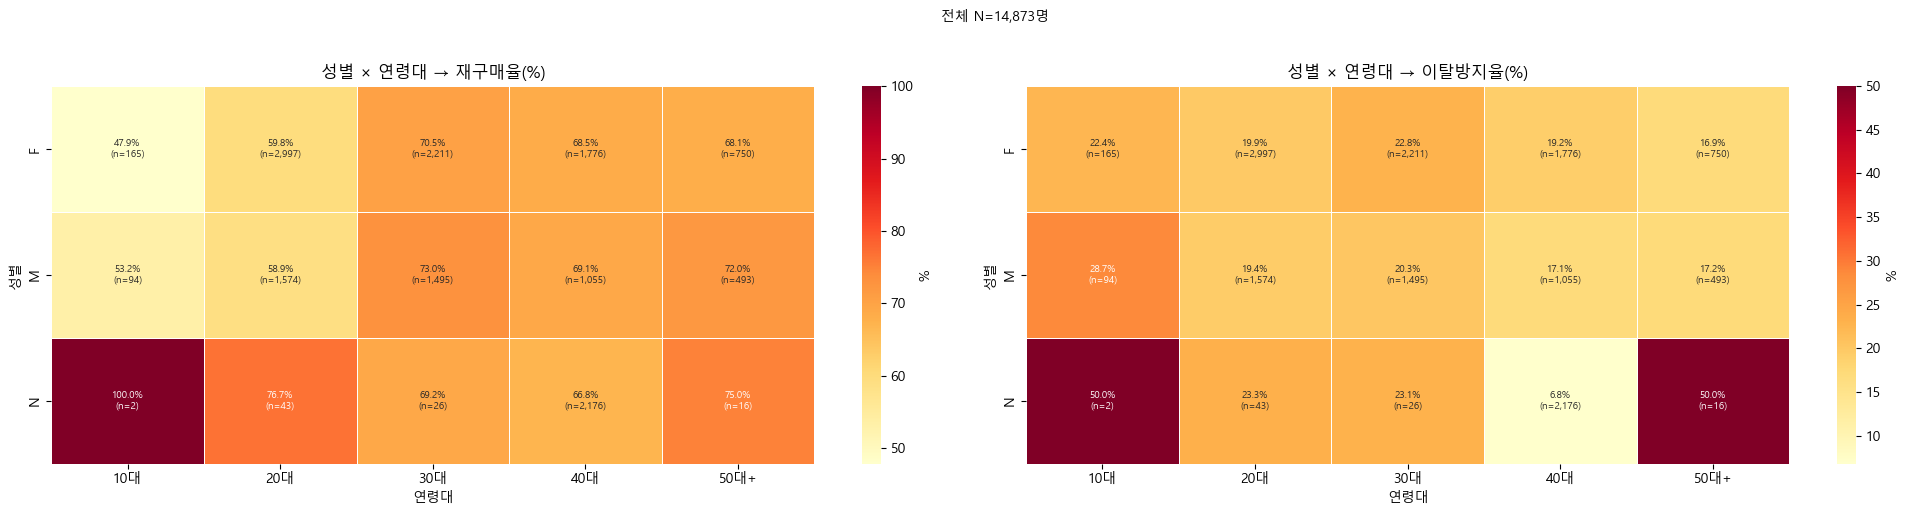

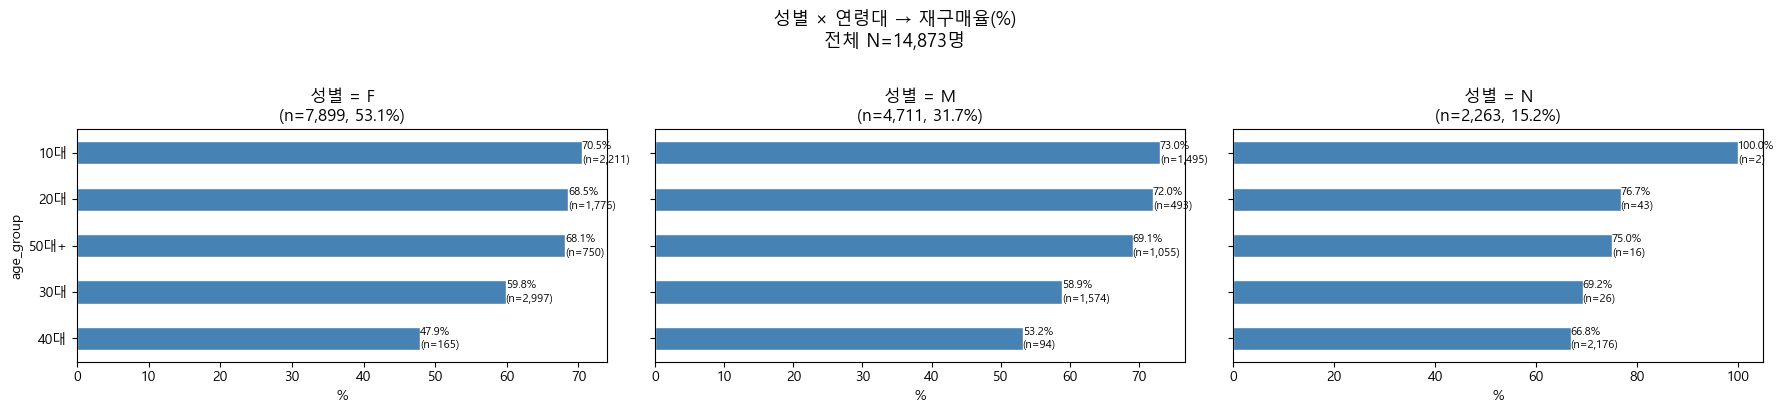

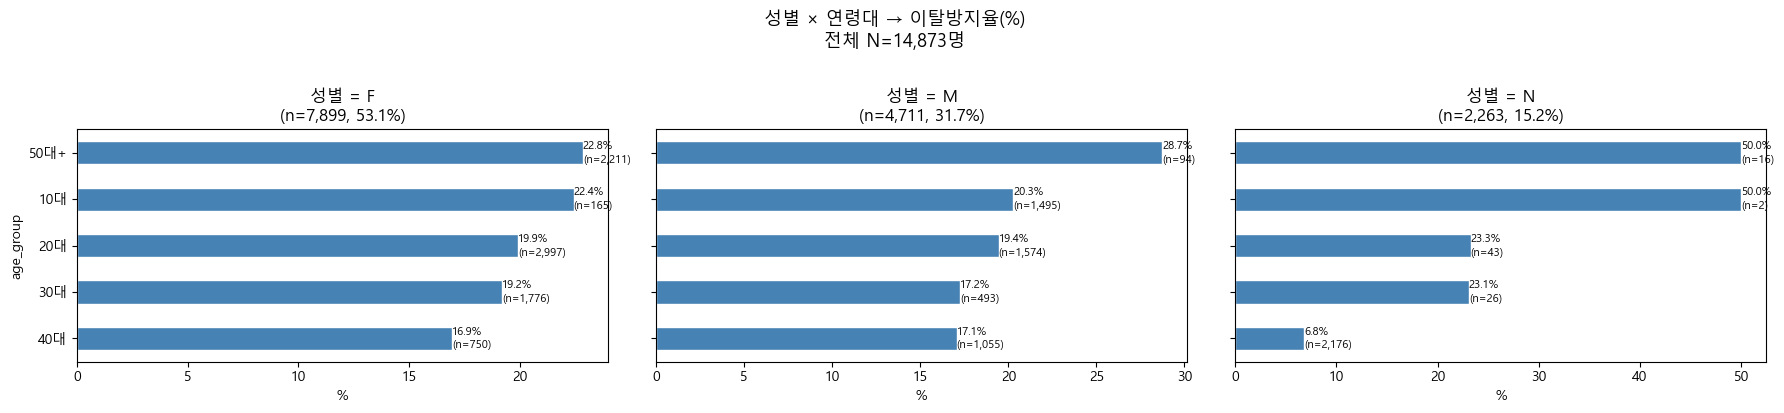

=== 성별 × 연령대별 재구매율/이탈방지율 (%) ===
                  is_repurchase  is_churn_prevented
gender age_group                                   
F      10대                47.88               22.42
       20대                59.83               19.92
       30대                70.47               22.84
       40대                68.52               19.20
       50대+               68.13               16.93
M      10대                53.19               28.72
       20대                58.89               19.44
       30대                73.04               20.27
       40대                69.10               17.06
       50대+               72.01               17.24
N      10대               100.00               50.00
       20대                76.74               23.26
       30대                69.23               23.08
       40대                66.82                6.80
       50대+               75.00               50.00


In [27]:
two_var_heatmap(df, 'gender', 'age_group', '성별', '연령대', figsize=(20, 5))

for outcome in OUTCOMES:
    two_var_barplot(df, 'gender', '성별', 'age_group', '연령대', outcome, figsize=(18, 4))

print('=== 성별 × 연령대별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['gender', 'age_group'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 2. gender × payment_device (성별 × 결제기기)

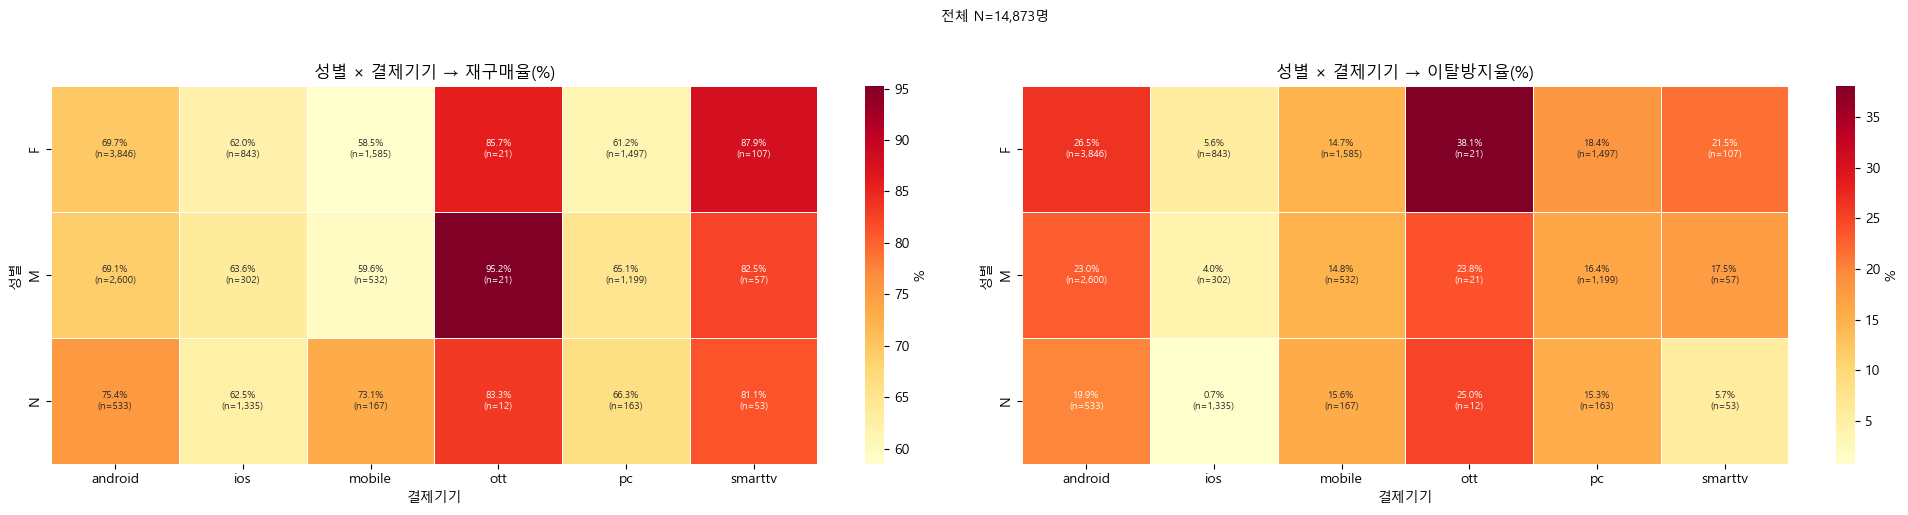

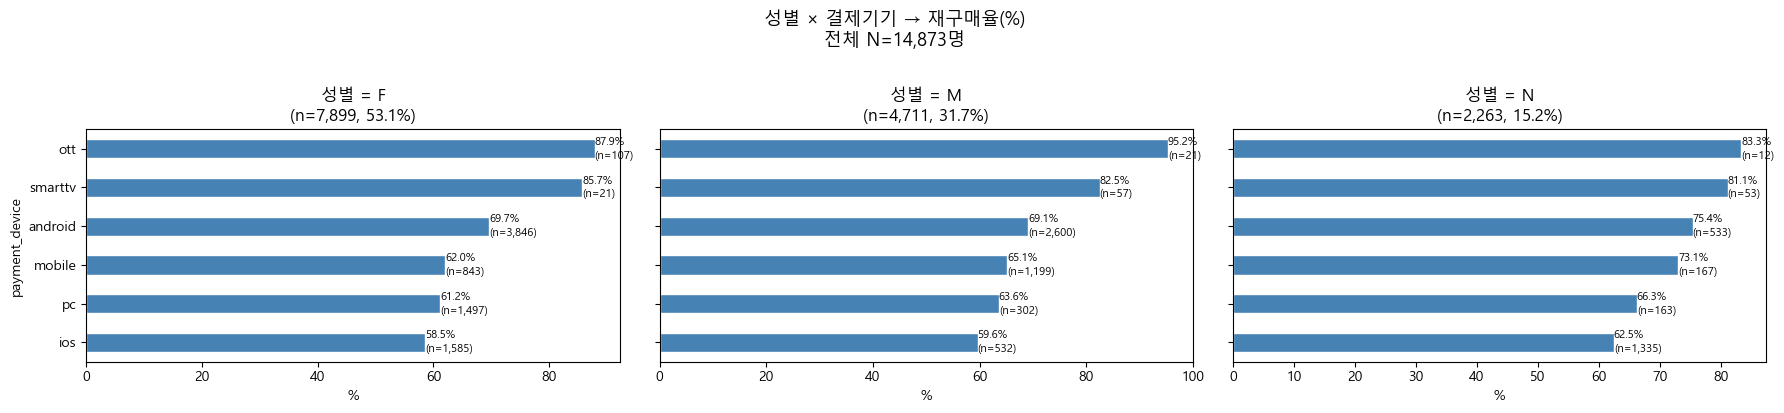

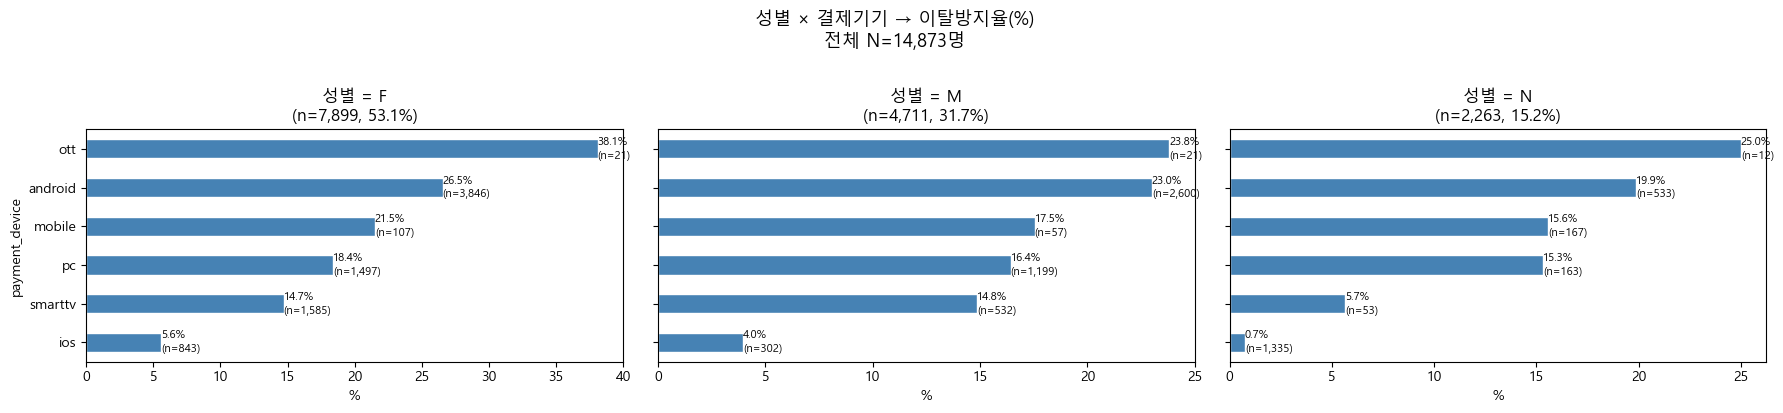

=== 성별 × 결제기기별 재구매율/이탈방지율 (%) ===
                       is_repurchase  is_churn_prevented
gender payment_device                                   
F      android                 69.66               26.55
       ios                     62.04                5.58
       mobile                  58.55               14.70
       ott                     85.71               38.10
       pc                      61.19               18.37
       smarttv                 87.85               21.50
M      android                 69.08               23.00
       ios                     63.58                3.97
       mobile                  59.59               14.85
       ott                     95.24               23.81
       pc                      65.14               16.43
       smarttv                 82.46               17.54
N      android                 75.42               19.89
       ios                     62.47                0.75
       mobile                  73.05               15.

In [28]:
two_var_heatmap(df, 'gender', 'payment_device', '성별', '결제기기', figsize=(20, 5))

for outcome in OUTCOMES:
    two_var_barplot(df, 'gender', '성별', 'payment_device', '결제기기', outcome, figsize=(18, 4))

print('=== 성별 × 결제기기별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['gender', 'payment_device'])[OUTCOMES].mean().mul(100).round(2))

---
## 3. gender × max_screen (성별 × 동시접속수)

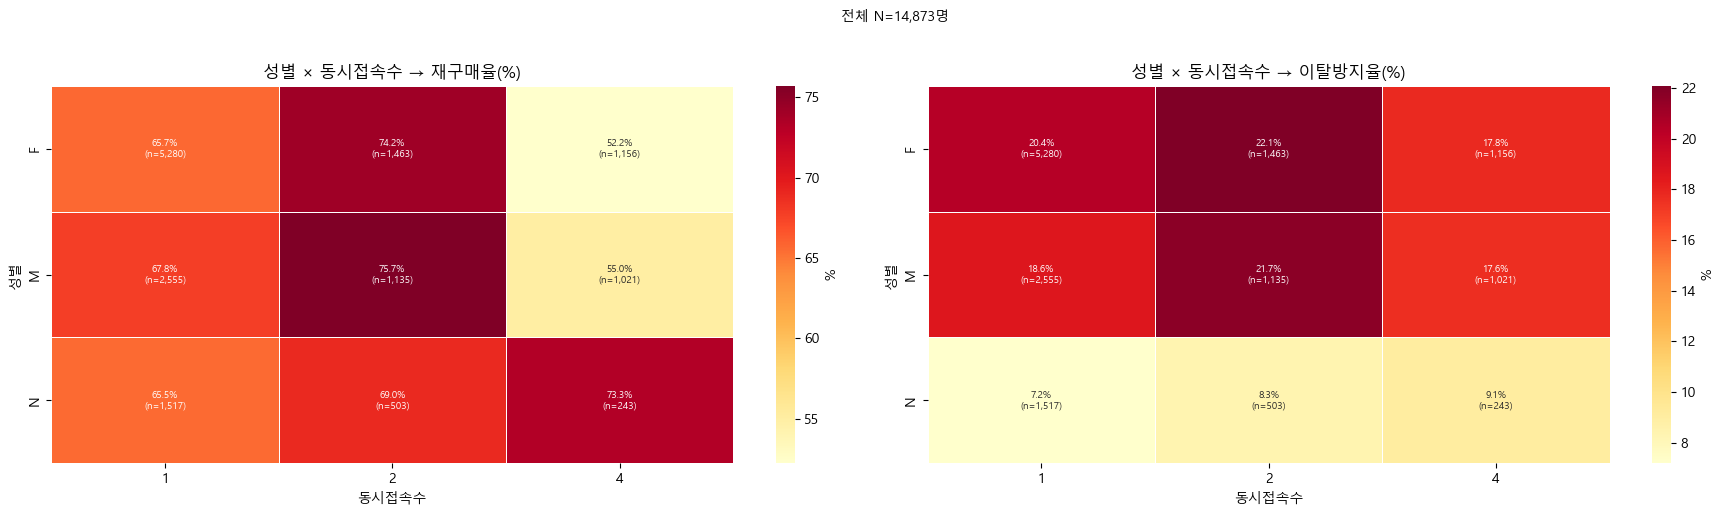

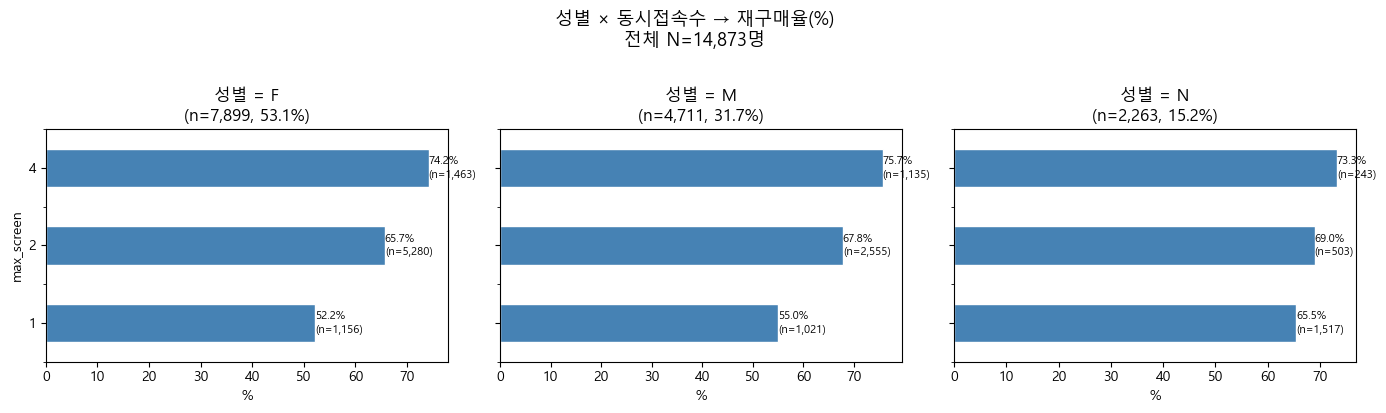

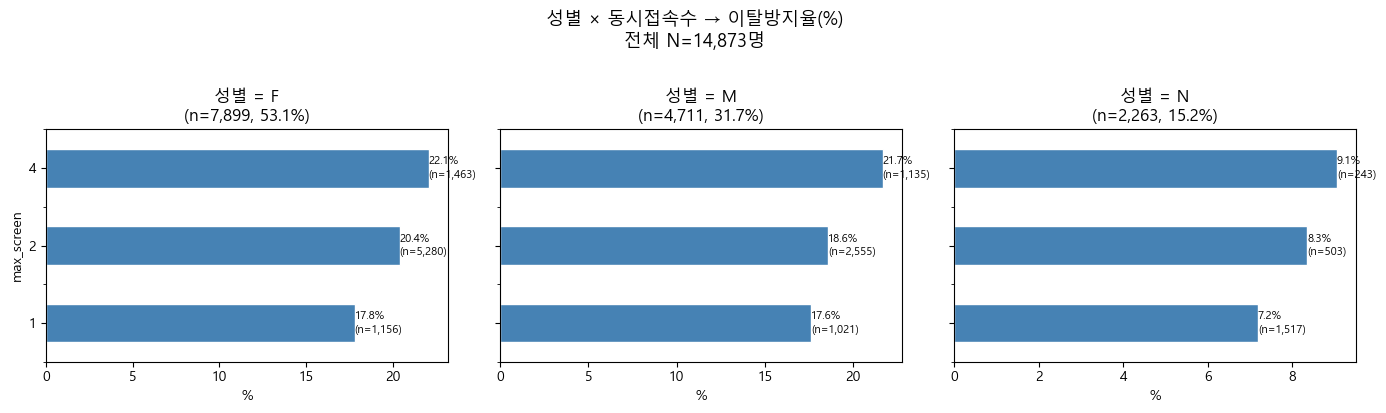

=== 성별 × 동시접속수별 재구매율/이탈방지율 (%) ===
                   is_repurchase  is_churn_prevented
gender max_screen                                   
F      1                   65.70               20.42
       2                   74.16               22.08
       4                   52.25               17.82
M      1                   67.79               18.59
       2                   75.68               21.67
       4                   55.04               17.63
N      1                   65.52                7.19
       2                   68.99                8.35
       4                   73.25                9.05


In [29]:
two_var_heatmap(df, 'gender', 'max_screen', '성별', '동시접속수')

for outcome in OUTCOMES:
    two_var_barplot(df, 'gender', '성별', 'max_screen', '동시접속수', outcome, figsize=(14, 4))

print('=== 성별 × 동시접속수별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['gender', 'max_screen'])[OUTCOMES].mean().mul(100).round(2))

---
## 4. age_group × payment_device (연령대 × 결제기기)

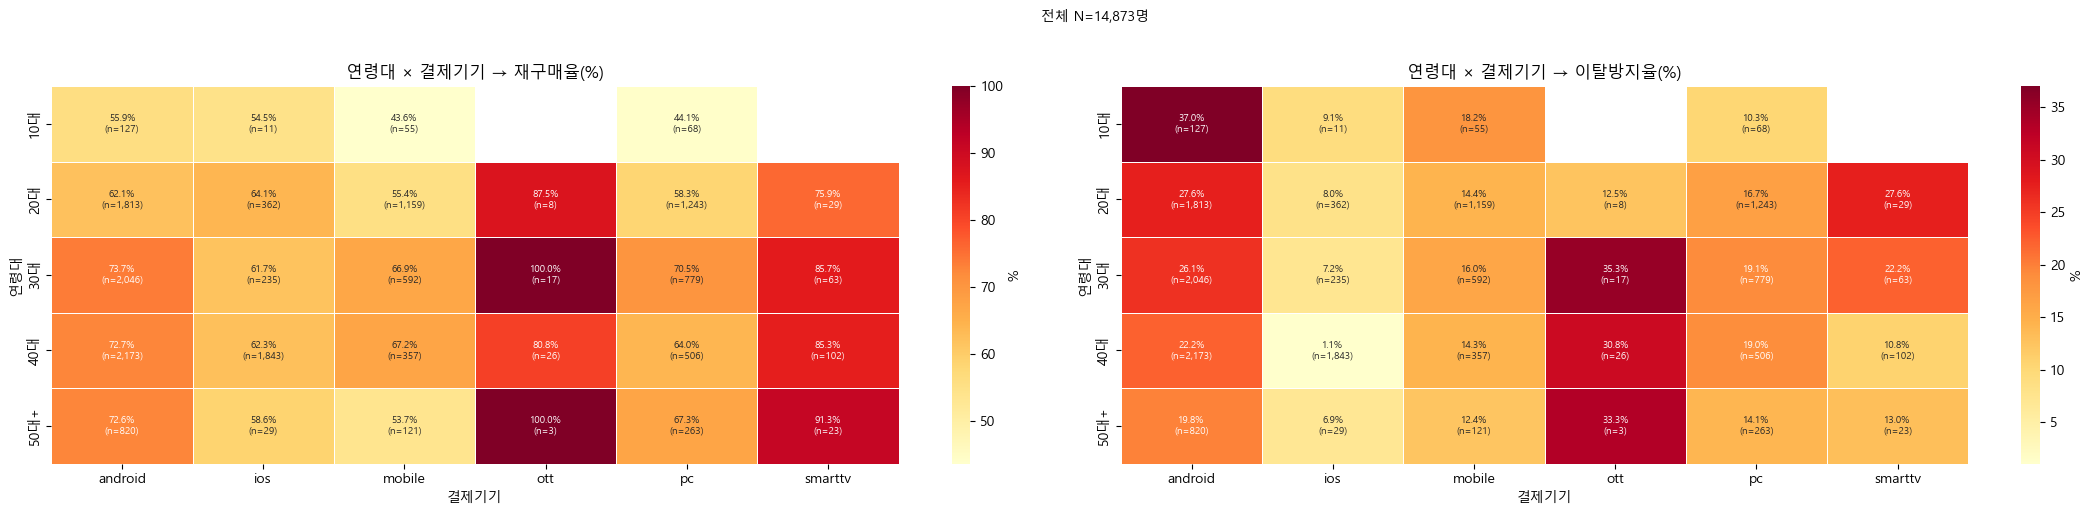

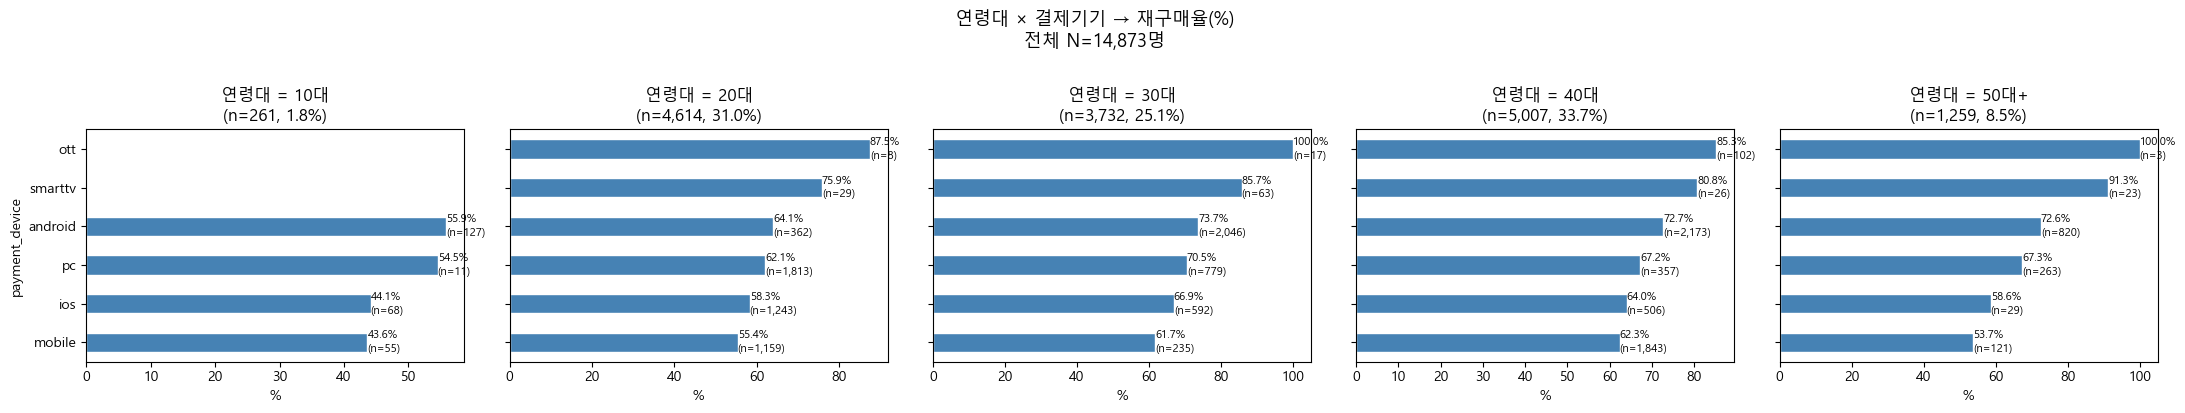

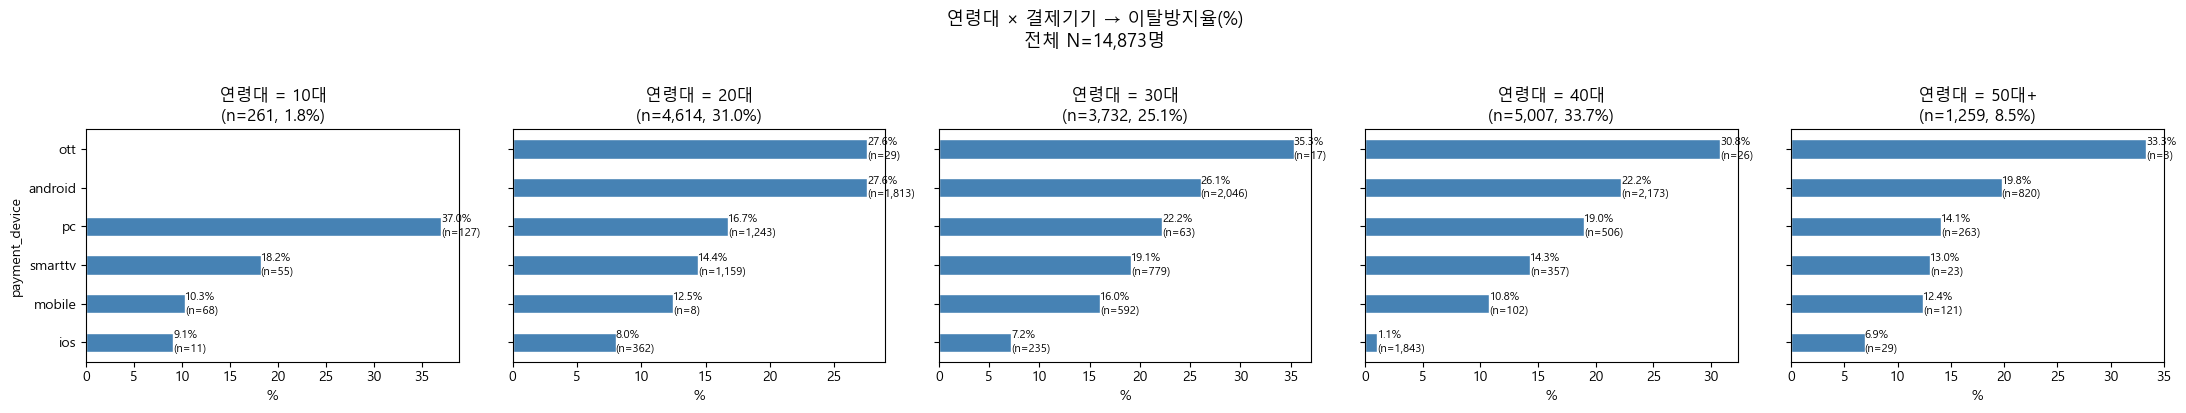

=== 연령대 × 결제기기별 재구매율/이탈방지율 (%) ===
                          is_repurchase  is_churn_prevented
age_group payment_device                                   
10대       android                 55.91               37.01
          ios                     54.55                9.09
          mobile                  43.64               18.18
          pc                      44.12               10.29
20대       android                 62.05               27.58
          ios                     64.09                8.01
          mobile                  55.39               14.41
          ott                     87.50               12.50
          pc                      58.33               16.73
          smarttv                 75.86               27.59
30대       android                 73.66               26.05
          ios                     61.70                7.23
          mobile                  66.89               16.05
          ott                    100.00               35.29
     

In [30]:
two_var_heatmap(df, 'age_group', 'payment_device', '연령대', '결제기기', figsize=(22, 5))

for outcome in OUTCOMES:
    two_var_barplot(df, 'age_group', '연령대', 'payment_device', '결제기기', outcome, figsize=(22, 4))

print('=== 연령대 × 결제기기별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['age_group', 'payment_device'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 5. age_group × max_screen (연령대 × 동시접속수)

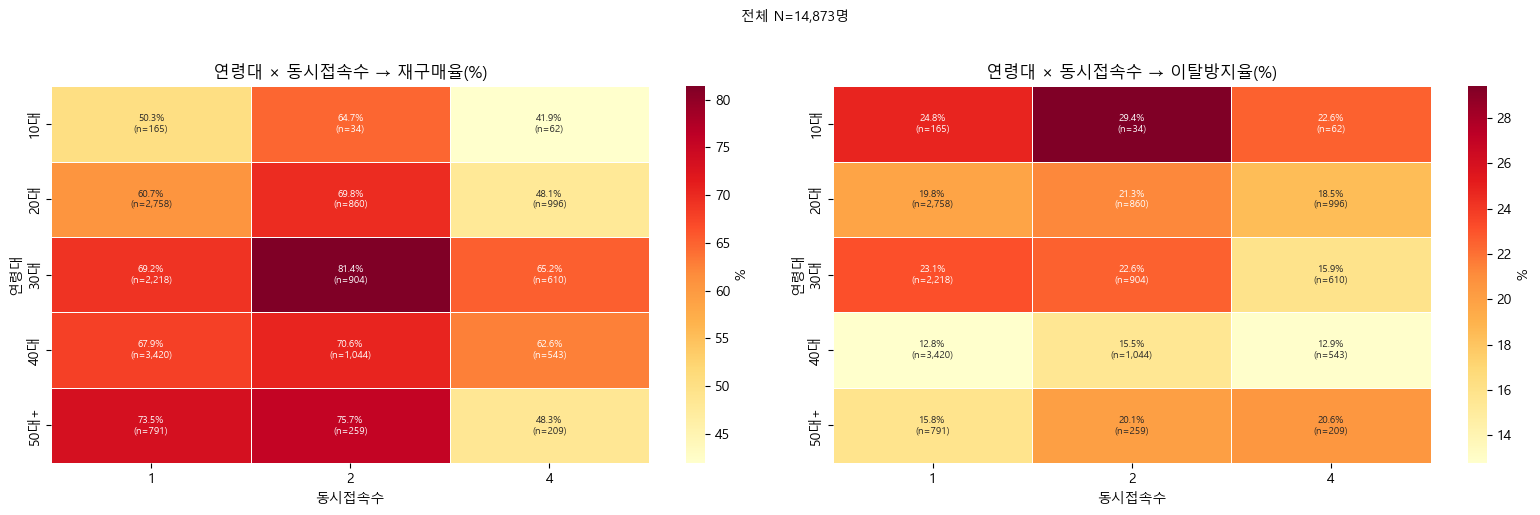

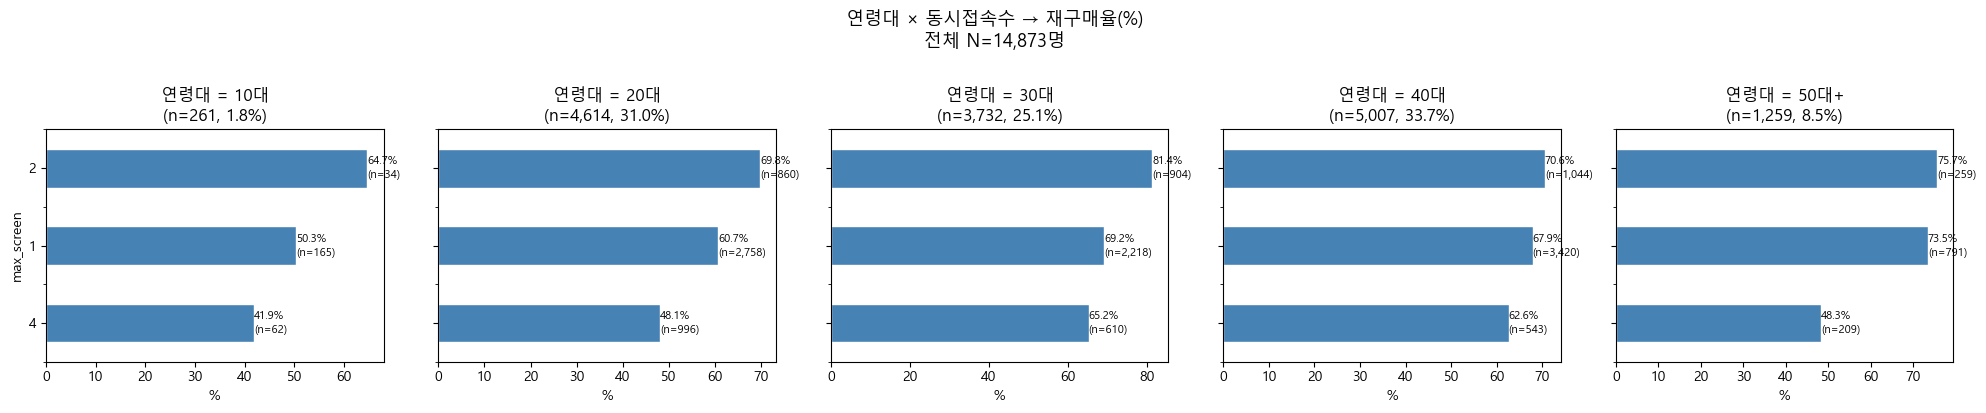

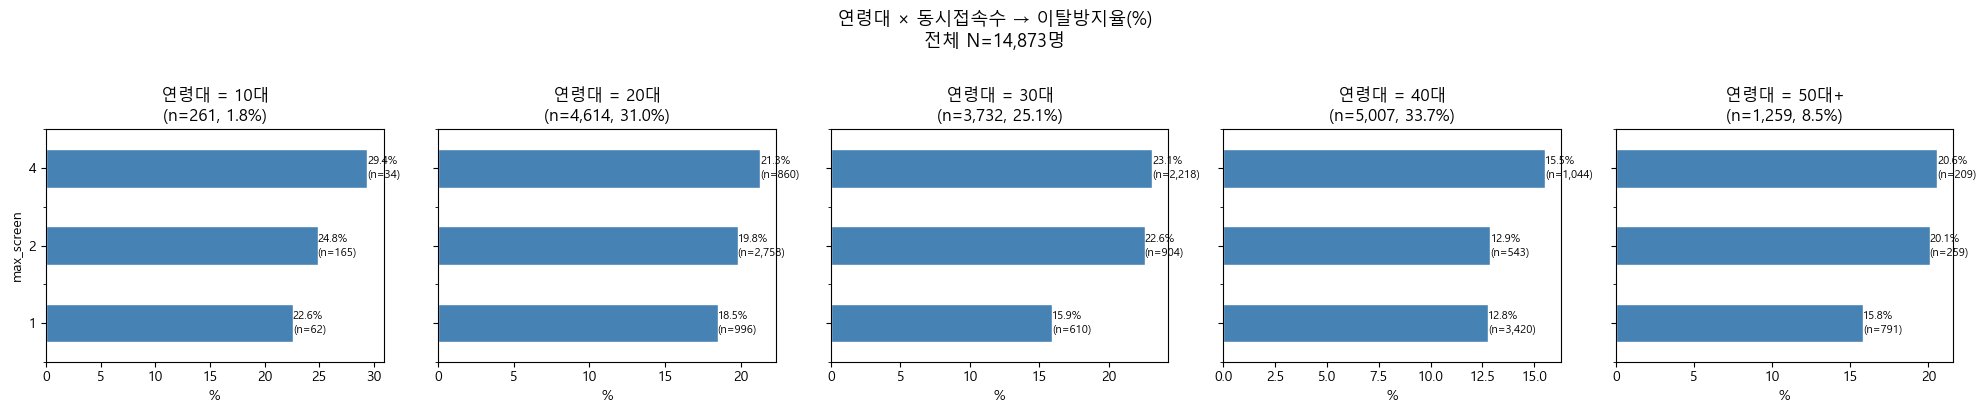

=== 연령대 × 동시접속수별 재구매율/이탈방지율 (%) ===
                      is_repurchase  is_churn_prevented
age_group max_screen                                   
10대       1                   50.30               24.85
          2                   64.71               29.41
          4                   41.94               22.58
20대       1                   60.70               19.80
          2                   69.77               21.28
          4                   48.09               18.47
30대       1                   69.16               23.13
          2                   81.42               22.57
          4                   65.25               15.90
40대       1                   67.92               12.78
          2                   70.59               15.52
          4                   62.62               12.89
50대+      1                   73.45               15.80
          2                   75.68               20.08
          4                   48.33               20.57


In [31]:
two_var_heatmap(df, 'age_group', 'max_screen', '연령대', '동시접속수', figsize=(16, 5))

for outcome in OUTCOMES:
    two_var_barplot(df, 'age_group', '연령대', 'max_screen', '동시접속수', outcome, figsize=(20, 4))

print('=== 연령대 × 동시접속수별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['age_group', 'max_screen'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 6. age_group × billing_method (연령대 × 결제방식)

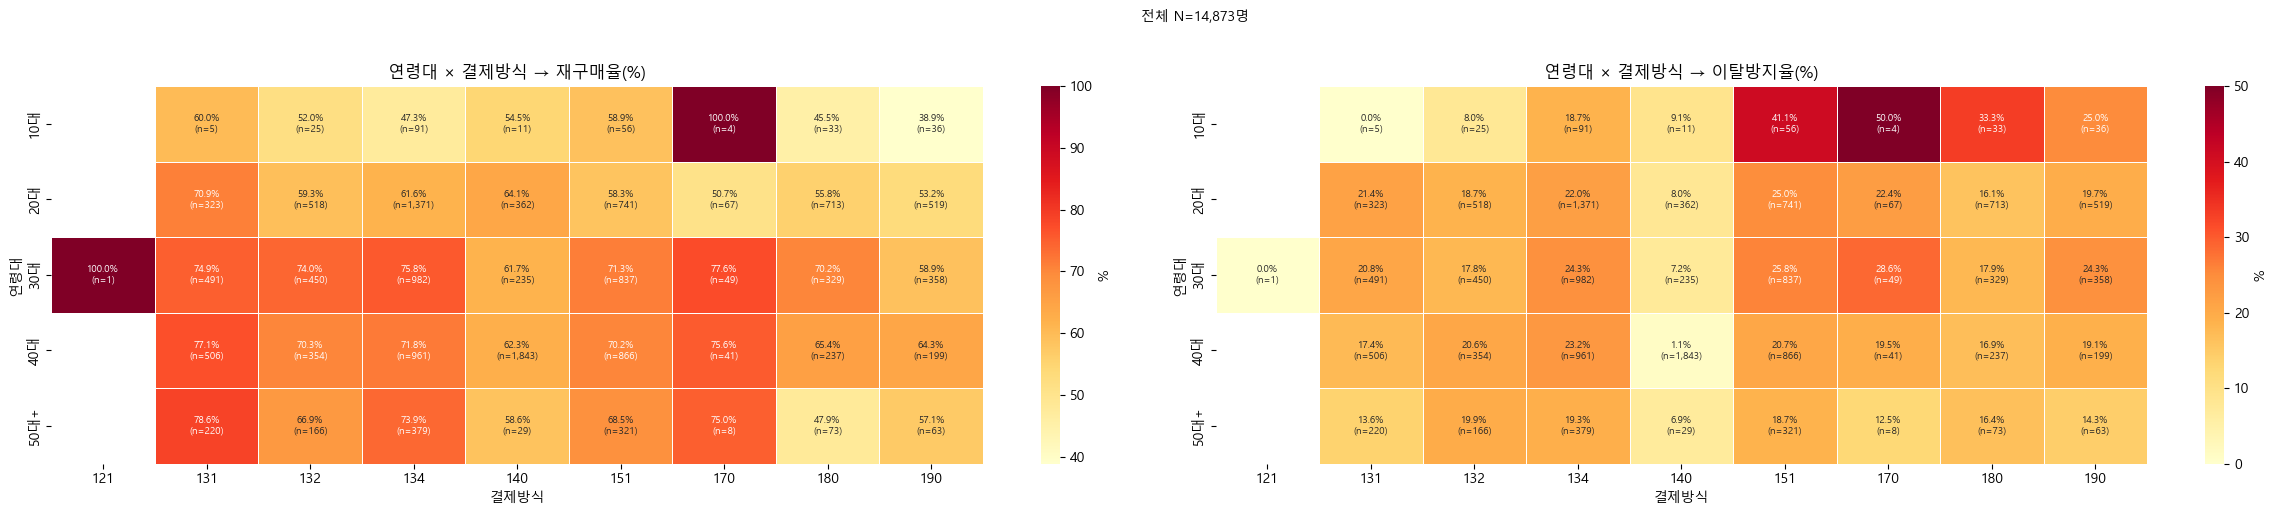

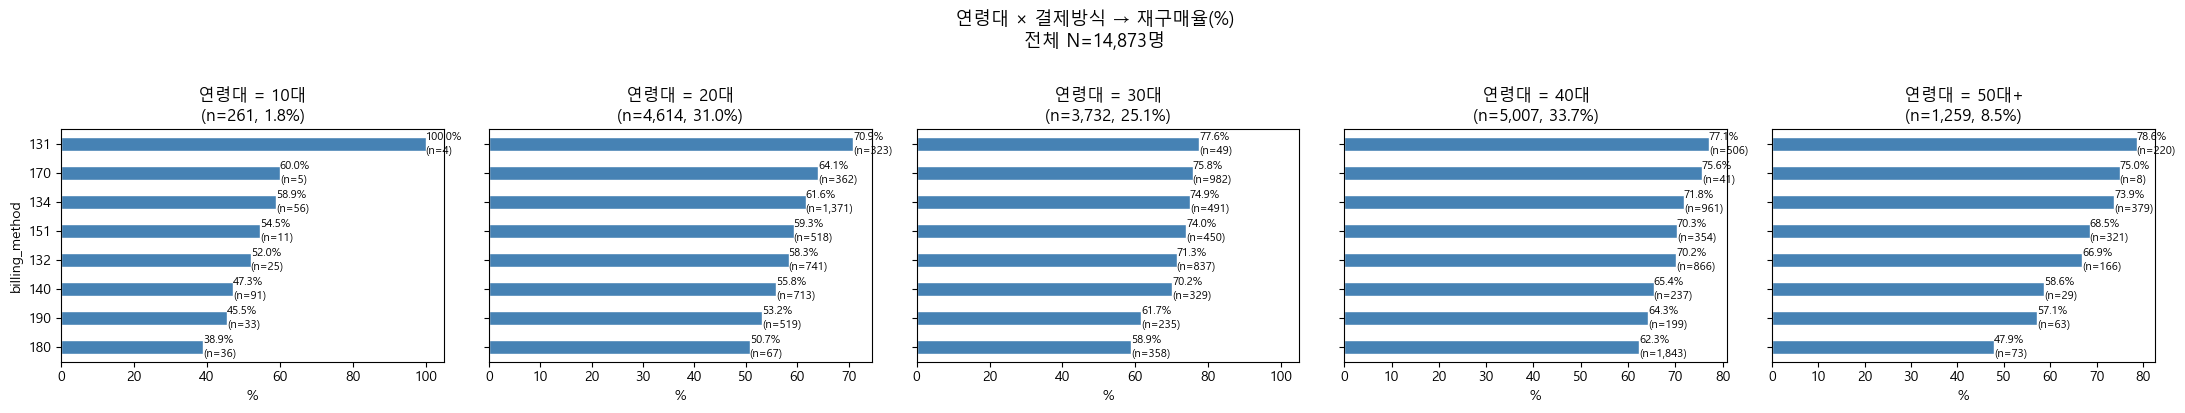

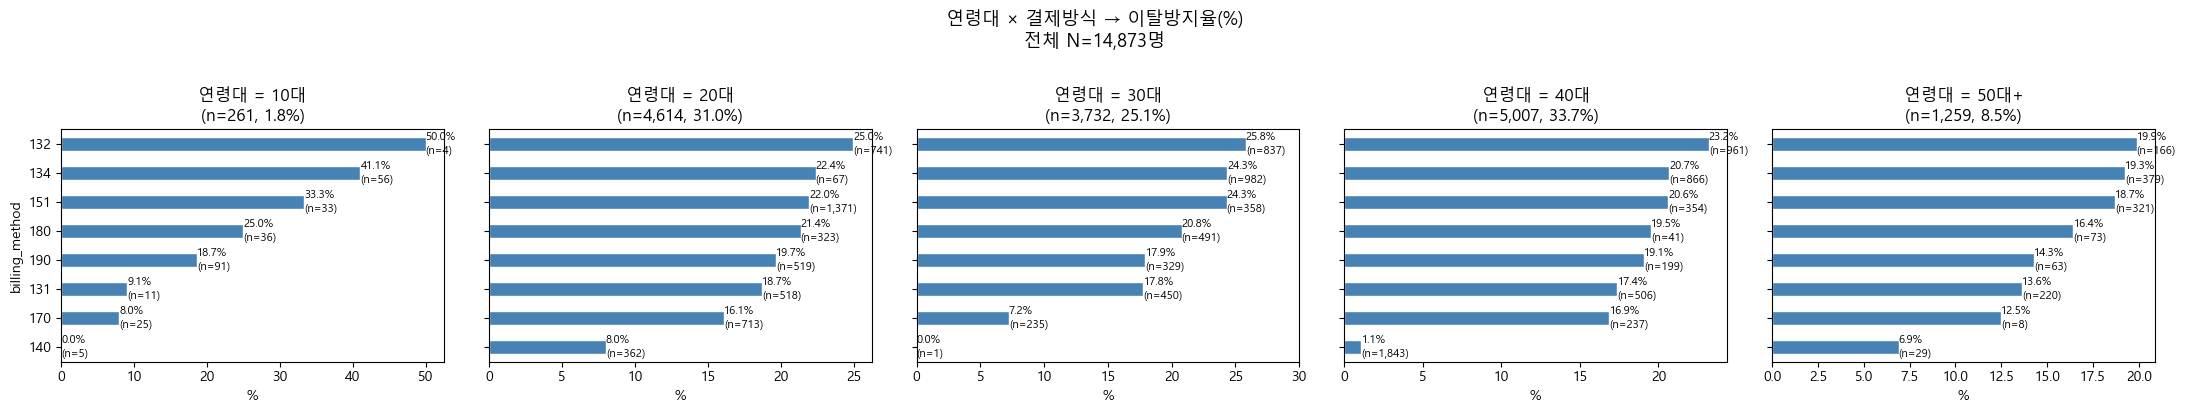

=== 연령대 × 결제방식별 재구매율/이탈방지율 (%) ===
                          is_repurchase  is_churn_prevented
age_group billing_method                                   
10대       131                     60.00                0.00
          132                     52.00                8.00
          134                     47.25               18.68
          140                     54.55                9.09
          151                     58.93               41.07
          170                    100.00               50.00
          180                     45.45               33.33
          190                     38.89               25.00
20대       131                     70.90               21.36
          132                     59.27               18.73
          134                     61.63               21.95
          140                     64.09                8.01
          151                     58.30               24.97
          170                     50.75               22.39
     

In [32]:
two_var_heatmap(df, 'age_group', 'billing_method', '연령대', '결제방식', figsize=(24, 5))

for outcome in OUTCOMES:
    two_var_barplot(df, 'age_group', '연령대', 'billing_method', '결제방식', outcome, figsize=(22, 4))

print('=== 연령대 × 결제방식별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['age_group', 'billing_method'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 7. is_repurchase × gender (재구매 여부 × 성별 → 이탈방지율)

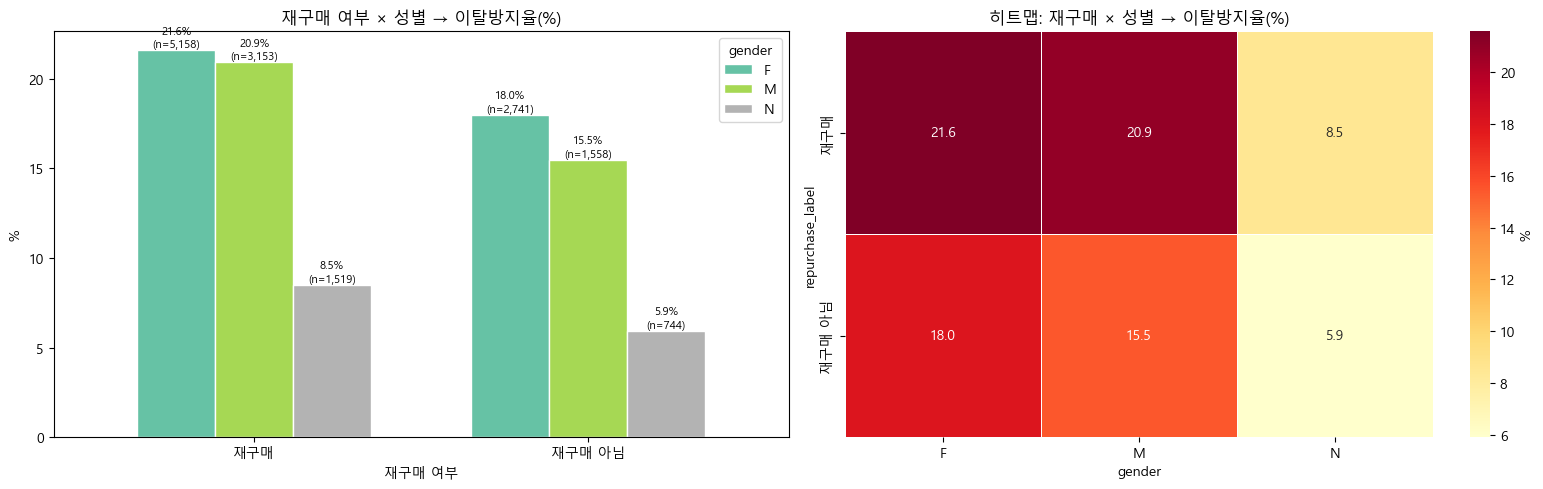

=== 재구매여부 × 성별별 이탈방지율 (%) ===
gender                F      M     N
repurchase_label                    
재구매               21.60  20.93  8.49
재구매 아님            17.99  15.47  5.91


In [33]:
pivot = df.groupby(['repurchase_label', 'gender'])['is_churn_prevented'].mean().mul(100).unstack('gender')
cnt = df.groupby(['repurchase_label', 'gender']).size().unstack('gender')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('재구매 여부 × 성별 → 이탈방지율(%)')
axes[0].set_xlabel('재구매 여부')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
n_idx = len(pivot)
for i, p in enumerate(axes[0].patches):
    h = p.get_height()
    if not np.isnan(h):
        col_name = pivot.columns[i // n_idx]
        row_name = pivot.index[i % n_idx]
        try:
            n = int(cnt.loc[row_name, col_name])
        except (KeyError, TypeError):
            n = 0
        axes[0].annotate(f'{h:.1f}%\n(n={n:,})', (p.get_x() + p.get_width()/2, h),
                         ha='center', va='bottom', fontsize=8)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('히트맵: 재구매 × 성별 → 이탈방지율(%)')
plt.tight_layout()
plt.show()

print('=== 재구매여부 × 성별별 이탈방지율 (%) ===')
print(pivot.round(2))

---
## 8. is_repurchase × age_group (재구매 여부 × 연령대 → 이탈방지율)

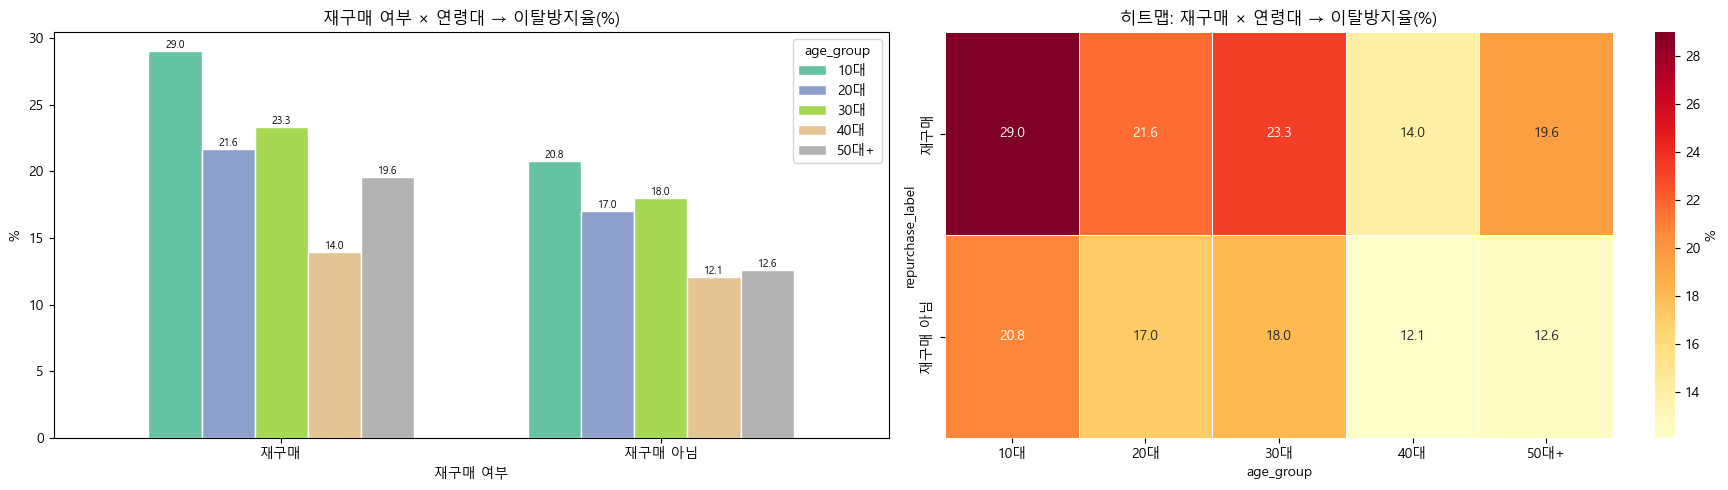

=== 재구매여부 × 연령대별 이탈방지율 (%) ===
age_group           10대    20대    30대    40대   50대+
repurchase_label                                   
재구매               29.01  21.65  23.31  13.97  19.59
재구매 아님            20.77  17.03  18.05  12.07  12.60


In [34]:
pivot = df.groupby(['repurchase_label', 'age_group'], observed=True)['is_churn_prevented'].mean().mul(100).unstack('age_group')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('재구매 여부 × 연령대 → 이탈방지율(%)')
axes[0].set_xlabel('재구매 여부')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h):
        axes[0].annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                         ha='center', va='bottom', fontsize=7.5)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('히트맵: 재구매 × 연령대 → 이탈방지율(%)')
plt.tight_layout()
plt.show()

print('=== 재구매여부 × 연령대별 이탈방지율 (%) ===')
print(pivot.round(2))

---
## 9. is_repurchase × payment_device (재구매 여부 × 결제기기 → 이탈방지율)

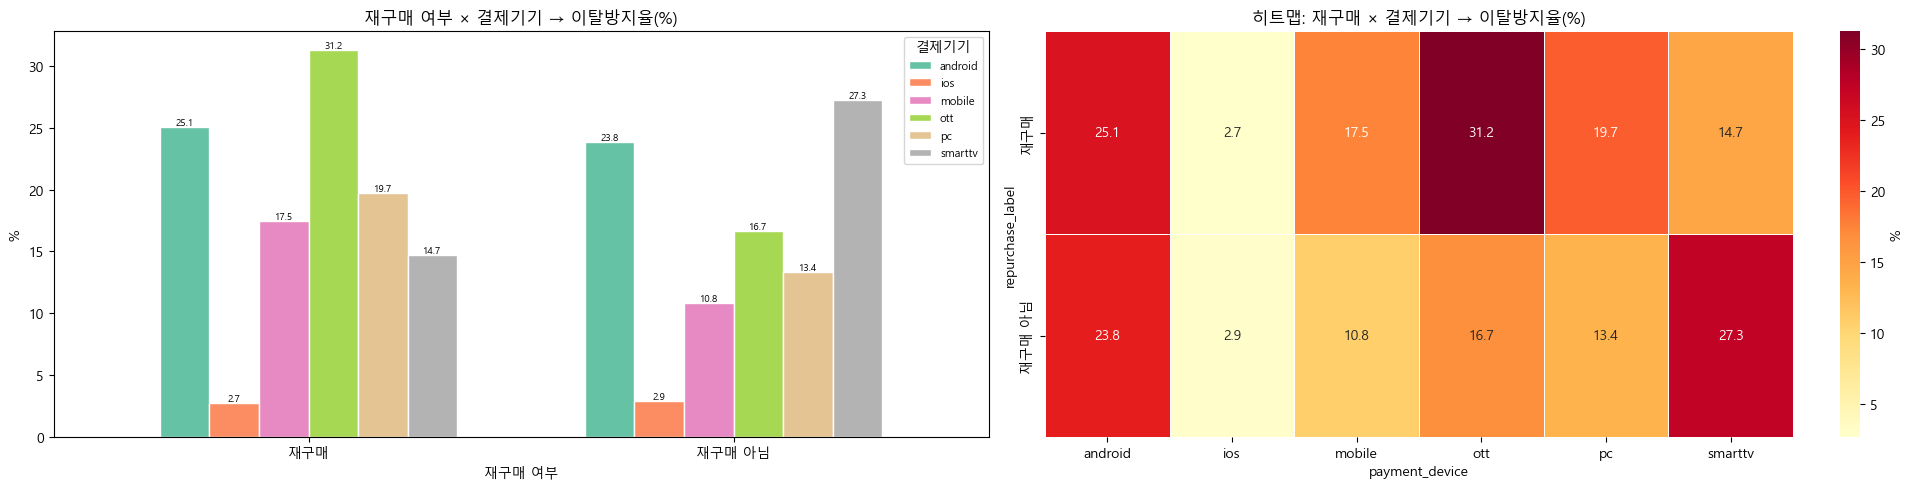

=== 재구매여부 × 결제기기별 이탈방지율 (%) ===
payment_device    android   ios  mobile    ott     pc  smarttv
repurchase_label                                              
재구매                 25.10  2.71   17.48  31.25  19.72    14.67
재구매 아님              23.83  2.90   10.80  16.67  13.38    27.27


In [35]:
pivot = df.groupby(['repurchase_label', 'payment_device'])['is_churn_prevented'].mean().mul(100).unstack('payment_device')

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('재구매 여부 × 결제기기 → 이탈방지율(%)')
axes[0].set_xlabel('재구매 여부')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='결제기기', fontsize=8)
for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h):
        axes[0].annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                         ha='center', va='bottom', fontsize=7)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('히트맵: 재구매 × 결제기기 → 이탈방지율(%)')
plt.tight_layout()
plt.show()

print('=== 재구매여부 × 결제기기별 이탈방지율 (%) ===')
print(pivot.round(2))

---
# 심화 교호작용 분석

---
## 10. reg_hour_group × gender (가입시간대 × 성별)

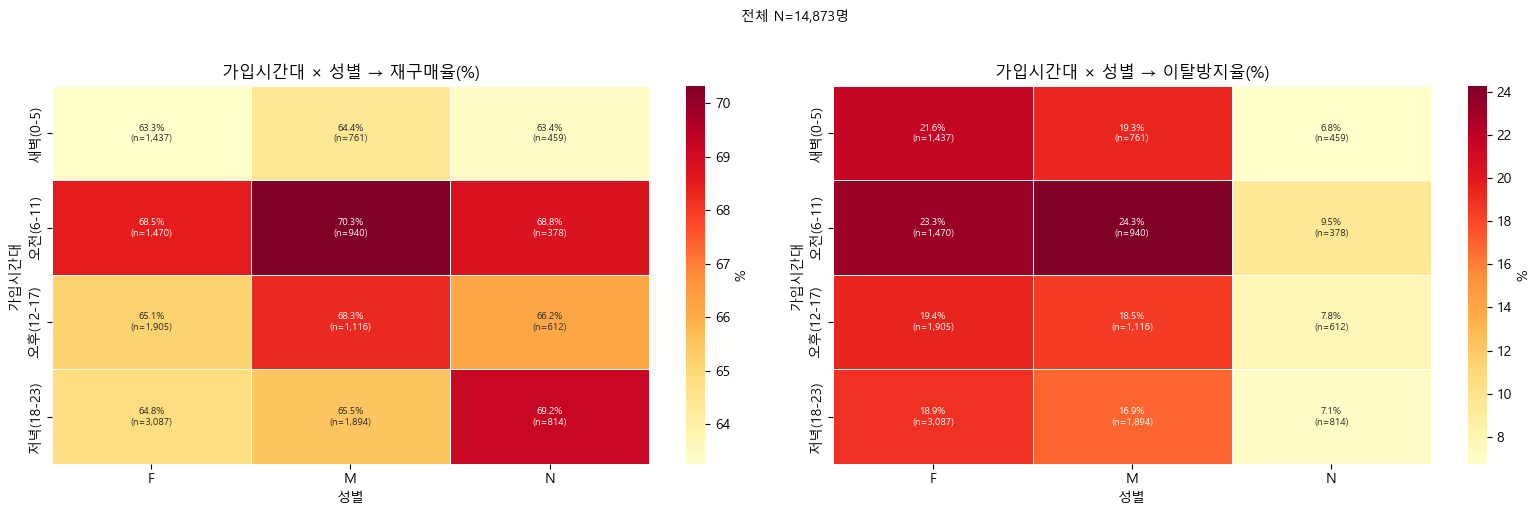

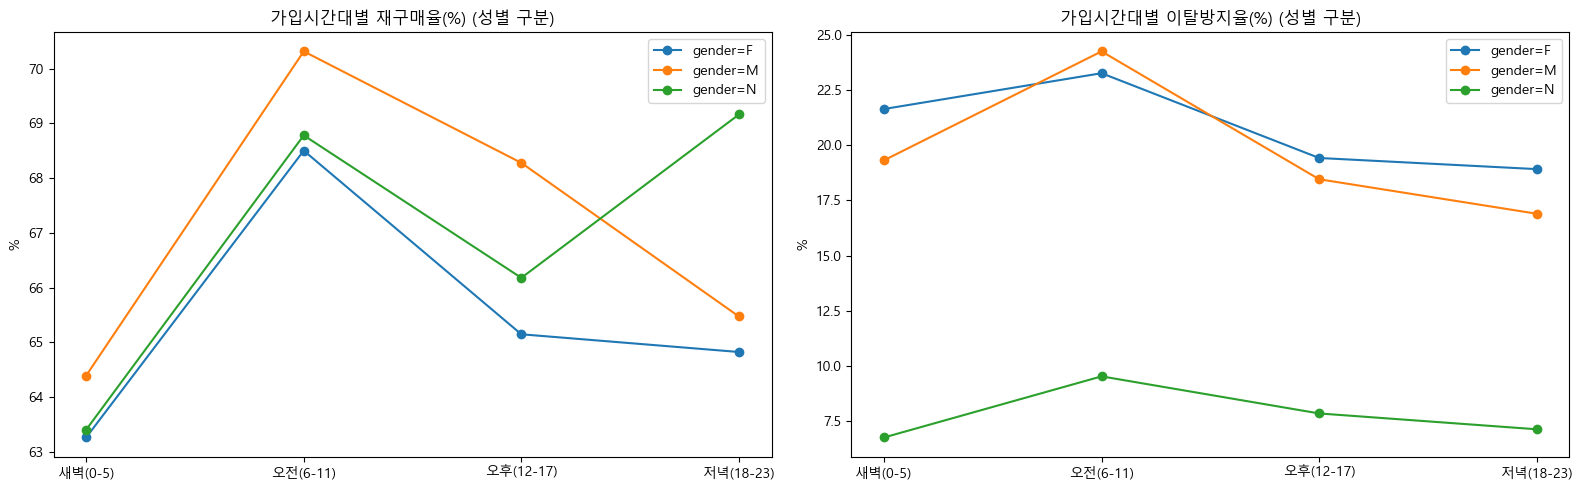

=== 가입시간대 × 성별별 재구매율/이탈방지율 (%) ===
                       is_repurchase  is_churn_prevented
reg_hour_group gender                                   
새벽(0-5)        F               63.26               21.64
               M               64.39               19.32
               N               63.40                6.75
오전(6-11)       F               68.50               23.27
               M               70.32               24.26
               N               68.78                9.52
오후(12-17)      F               65.14               19.42
               M               68.28               18.46
               N               66.18                7.84
저녁(18-23)      F               64.82               18.92
               M               65.47               16.90
               N               69.16                7.13


In [36]:
two_var_heatmap(df, 'reg_hour_group', 'gender', '가입시간대', '성별', figsize=(16, 5))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, outcome in zip(axes, OUTCOMES):
    for gender, sub in df.groupby('gender'):
        trend = sub.groupby('reg_hour_group', observed=True)[outcome].mean().mul(100)
        ax.plot(trend.index.astype(str), trend.values, marker='o', label=f'gender={gender}')
    ax.set_title(f'가입시간대별 {OUTCOME_LABELS[outcome]} (성별 구분)')
    ax.set_ylabel('%')
    ax.legend()
plt.tight_layout()
plt.show()

print('=== 가입시간대 × 성별별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['reg_hour_group', 'gender'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 11. reg_hour_group × age_group (가입시간대 × 연령대)

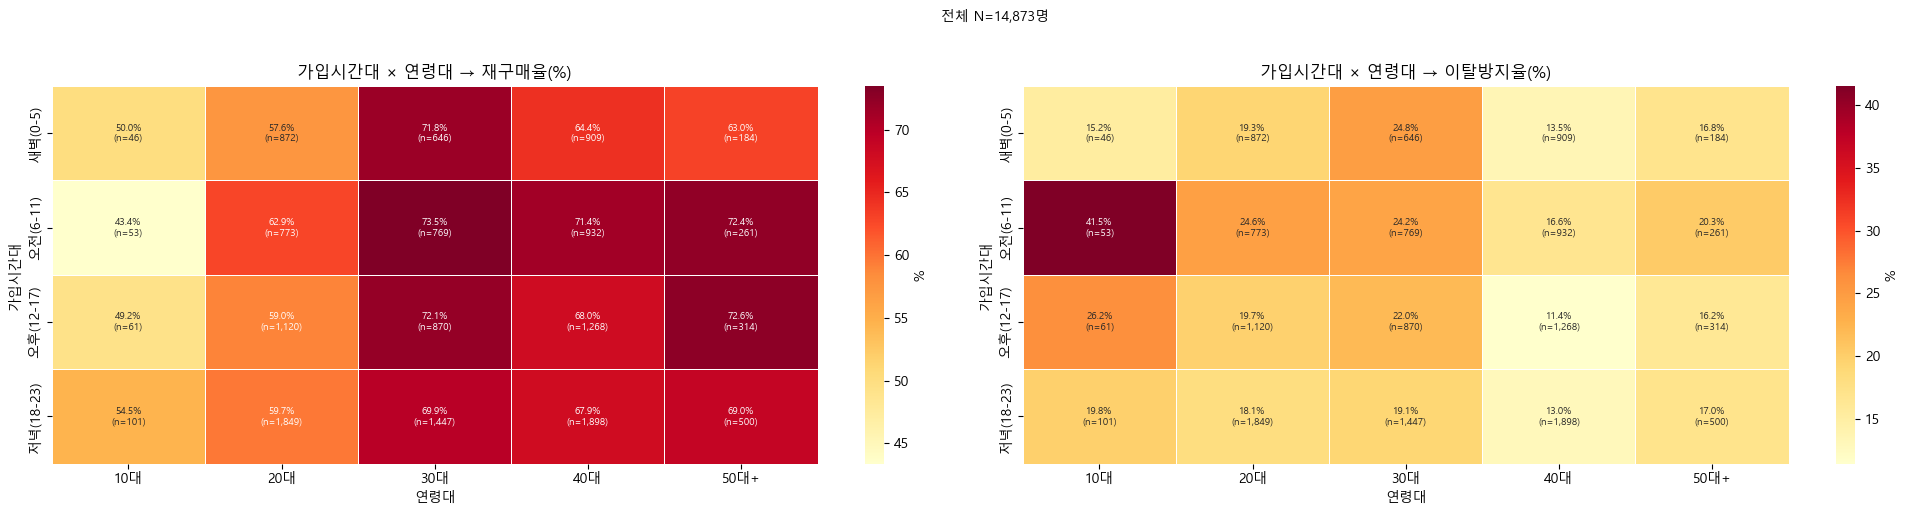

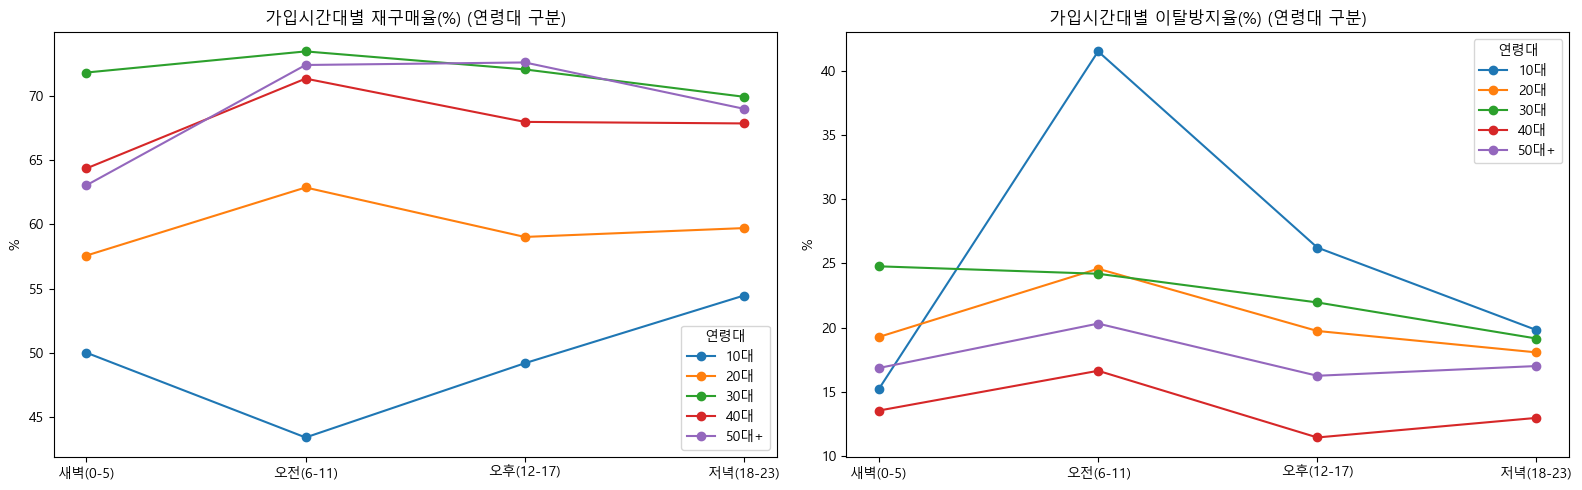

=== 가입시간대 × 연령대별 재구매율/이탈방지율 (%) ===
                          is_repurchase  is_churn_prevented
reg_hour_group age_group                                   
새벽(0-5)        10대                50.00               15.22
               20대                57.57               19.27
               30대                71.83               24.77
               40대                64.36               13.53
               50대+               63.04               16.85
오전(6-11)       10대                43.40               41.51
               20대                62.87               24.58
               30대                73.47               24.19
               40대                71.35               16.63
               50대+               72.41               20.31
오후(12-17)      10대                49.18               26.23
               20대                59.02               19.73
               30대                72.07               21.95
               40대                67.98               11.44
    

In [37]:
two_var_heatmap(df, 'reg_hour_group', 'age_group', '가입시간대', '연령대', figsize=(20, 5))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, outcome in zip(axes, OUTCOMES):
    for age, sub in df.groupby('age_group', observed=True):
        trend = sub.groupby('reg_hour_group', observed=True)[outcome].mean().mul(100)
        ax.plot(trend.index.astype(str), trend.values, marker='o', label=str(age))
    ax.set_title(f'가입시간대별 {OUTCOME_LABELS[outcome]} (연령대 구분)')
    ax.set_ylabel('%')
    ax.legend(title='연령대')
plt.tight_layout()
plt.show()

print('=== 가입시간대 × 연령대별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['reg_hour_group', 'age_group'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 12. product_code × gender (상품코드 × 성별)

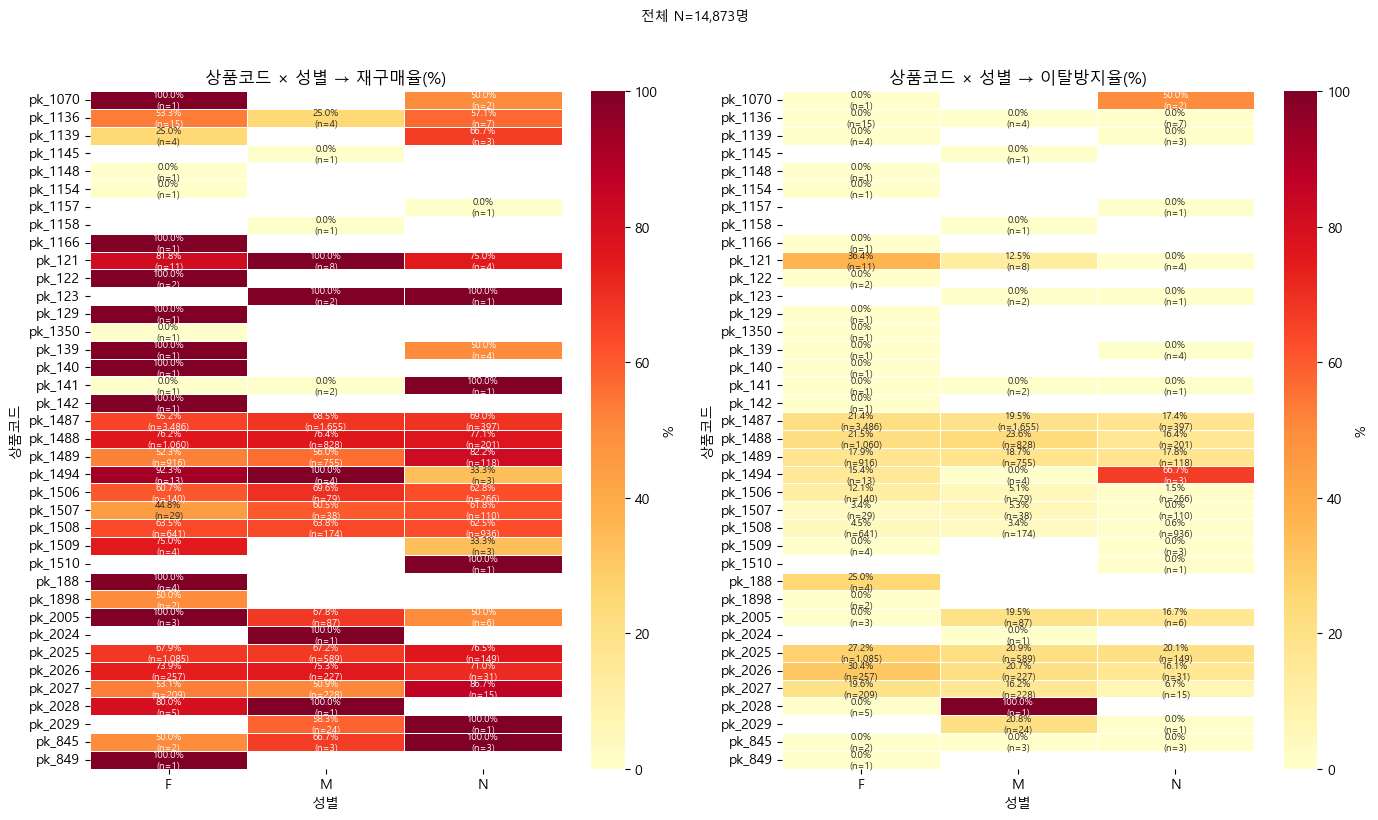

=== 상품코드 × 성별별 재구매율/이탈방지율 (%) ===
                     is_repurchase  is_churn_prevented
product_code gender                                   
pk_1070      F              100.00                 0.0
             N               50.00                50.0
pk_1136      F               53.33                 0.0
             M               25.00                 0.0
             N               57.14                 0.0
...                            ...                 ...
pk_2029      N              100.00                 0.0
pk_845       F               50.00                 0.0
             M               66.67                 0.0
             N              100.00                 0.0
pk_849       F              100.00                 0.0

[75 rows x 2 columns]

=== 상품코드 × 성별 샘플 수 ===
gender           F     M    N
product_code                 
pk_1070          1     0    2
pk_1136         15     4    7
pk_1139          4     0    3
pk_1145          0     1    0
pk_1148          1     0

In [38]:
two_var_heatmap(df, 'product_code', 'gender', '상품코드', '성별', figsize=(14, 8))

print('=== 상품코드 × 성별별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['product_code', 'gender'])[OUTCOMES].mean().mul(100).round(2))
print('\n=== 상품코드 × 성별 샘플 수 ===')
print(df.groupby(['product_code', 'gender']).size().unstack('gender').fillna(0).astype(int))

---
## 13. product_code × age_group (상품코드 × 연령대)

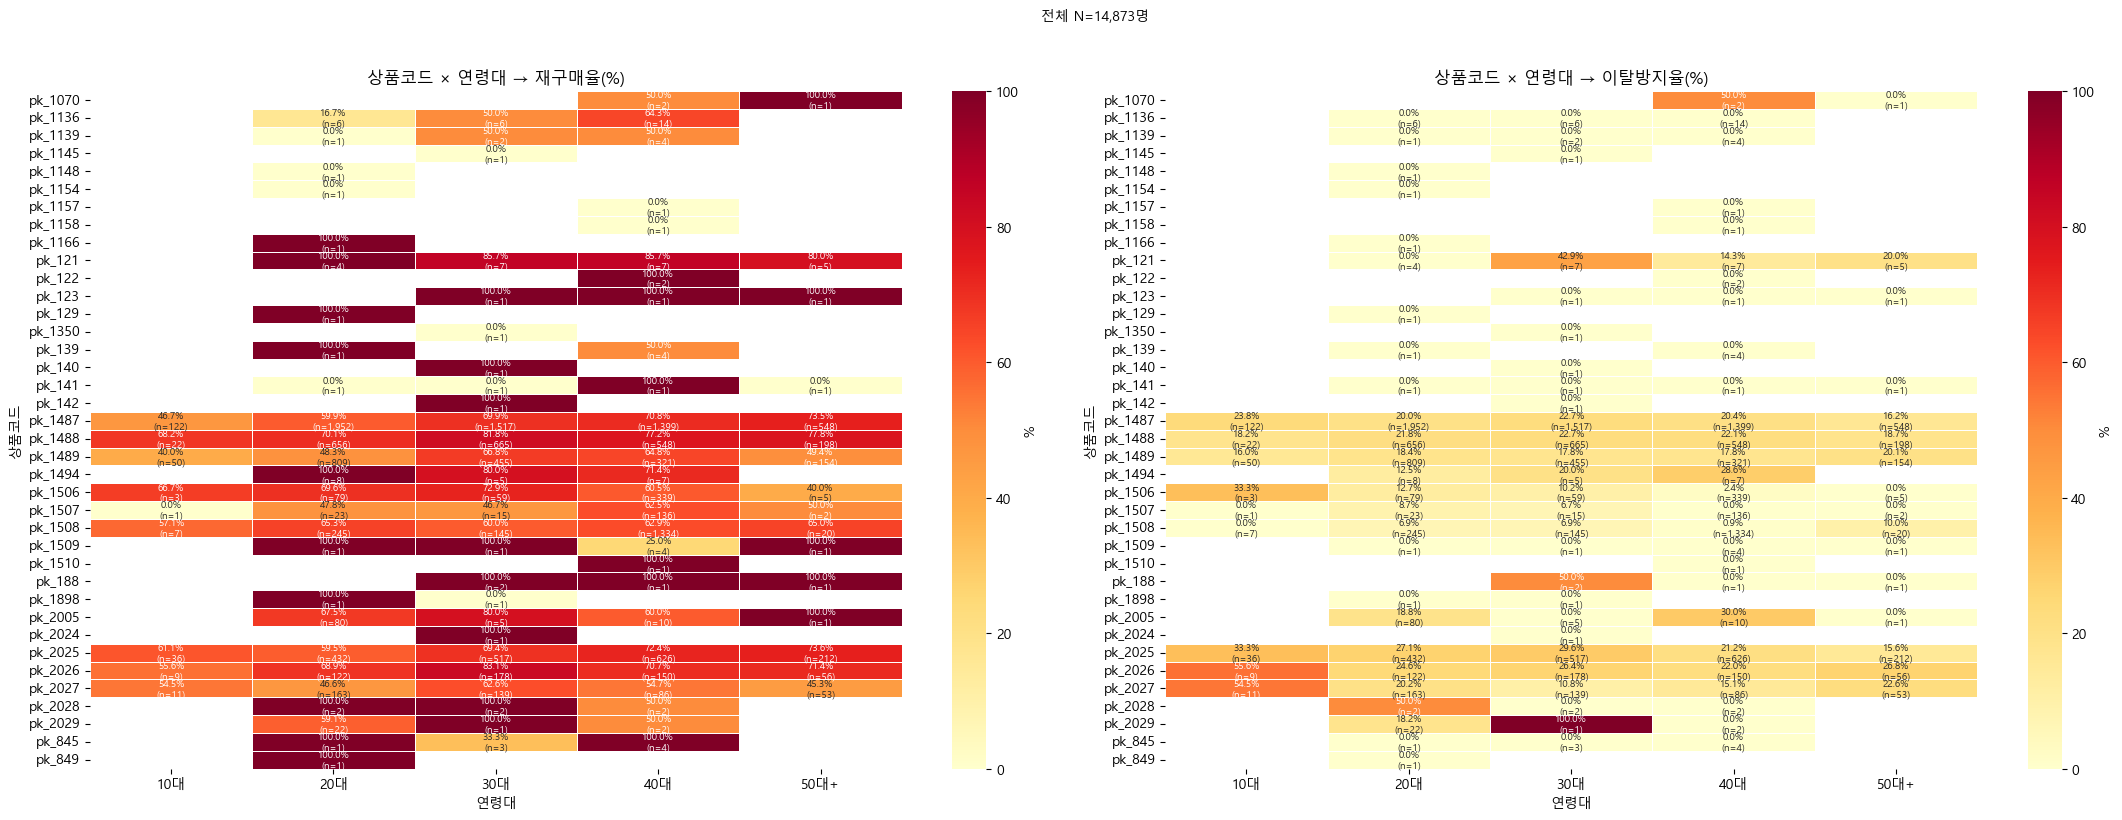

=== 상품코드 × 연령대별 재구매율/이탈방지율 (%) ===
                        is_repurchase  is_churn_prevented
product_code age_group                                   
pk_1070      40대                50.00                50.0
             50대+              100.00                 0.0
pk_1136      20대                16.67                 0.0
             30대                50.00                 0.0
             40대                64.29                 0.0
...                               ...                 ...
pk_2029      40대                50.00                 0.0
pk_845       20대               100.00                 0.0
             30대                33.33                 0.0
             40대               100.00                 0.0
pk_849       20대               100.00                 0.0

[105 rows x 2 columns]

=== 상품코드 × 연령대 샘플 수 ===
age_group     10대   20대   30대   40대  50대+
product_code                             
pk_1070         0     0     0     2     1
pk_1136         0     6     6    14 

In [39]:
two_var_heatmap(df, 'product_code', 'age_group', '상품코드', '연령대', figsize=(22, 8))

print('=== 상품코드 × 연령대별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['product_code', 'age_group'], observed=True)[OUTCOMES].mean().mul(100).round(2))
print('\n=== 상품코드 × 연령대 샘플 수 ===')
print(df.groupby(['product_code', 'age_group'], observed=True).size().unstack('age_group').fillna(0).astype(int))

---
## 14. billing_method × gender (결제방식 × 성별)

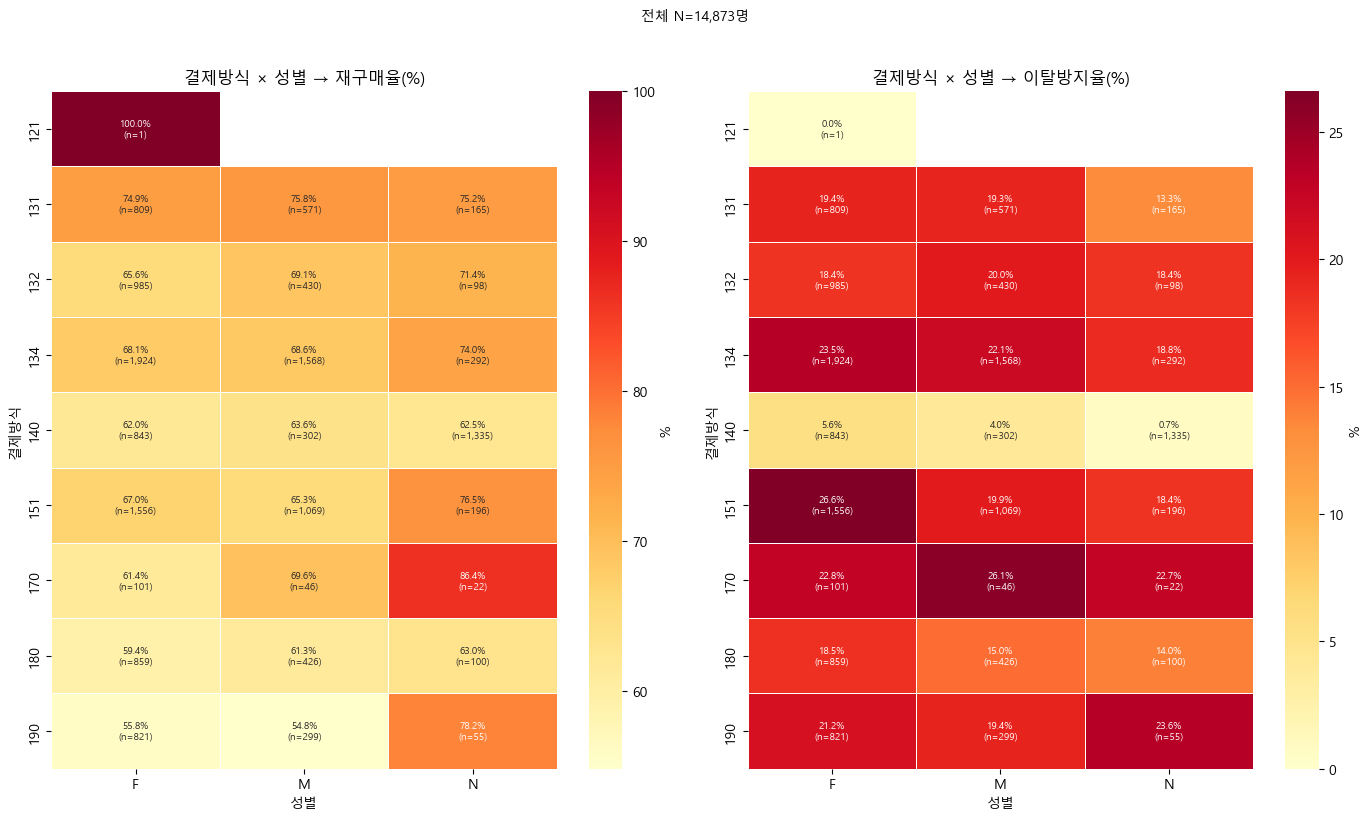

=== 결제방식 × 성별별 재구매율/이탈방지율 (%) ===
                       is_repurchase  is_churn_prevented
billing_method gender                                   
121            F              100.00                0.00
131            F               74.91               19.41
               M               75.83               19.26
               N               75.15               13.33
132            F               65.58               18.38
               M               69.07               20.00
               N               71.43               18.37
134            F               68.09               23.49
               M               68.62               22.07
               N               73.97               18.84
140            F               62.04                5.58
               M               63.58                3.97
               N               62.47                0.75
151            F               66.97               26.61
               M               65.29               19.

In [40]:
two_var_heatmap(df, 'billing_method', 'gender', '결제방식', '성별', figsize=(14, 8))

print('=== 결제방식 × 성별별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['billing_method', 'gender'])[OUTCOMES].mean().mul(100).round(2))
print('\n=== 결제방식 × 성별 샘플 수 ===')
print(df.groupby(['billing_method', 'gender']).size().unstack('gender').fillna(0).astype(int))

---
## 15. billing_method × payment_device (결제방식 × 결제기기)

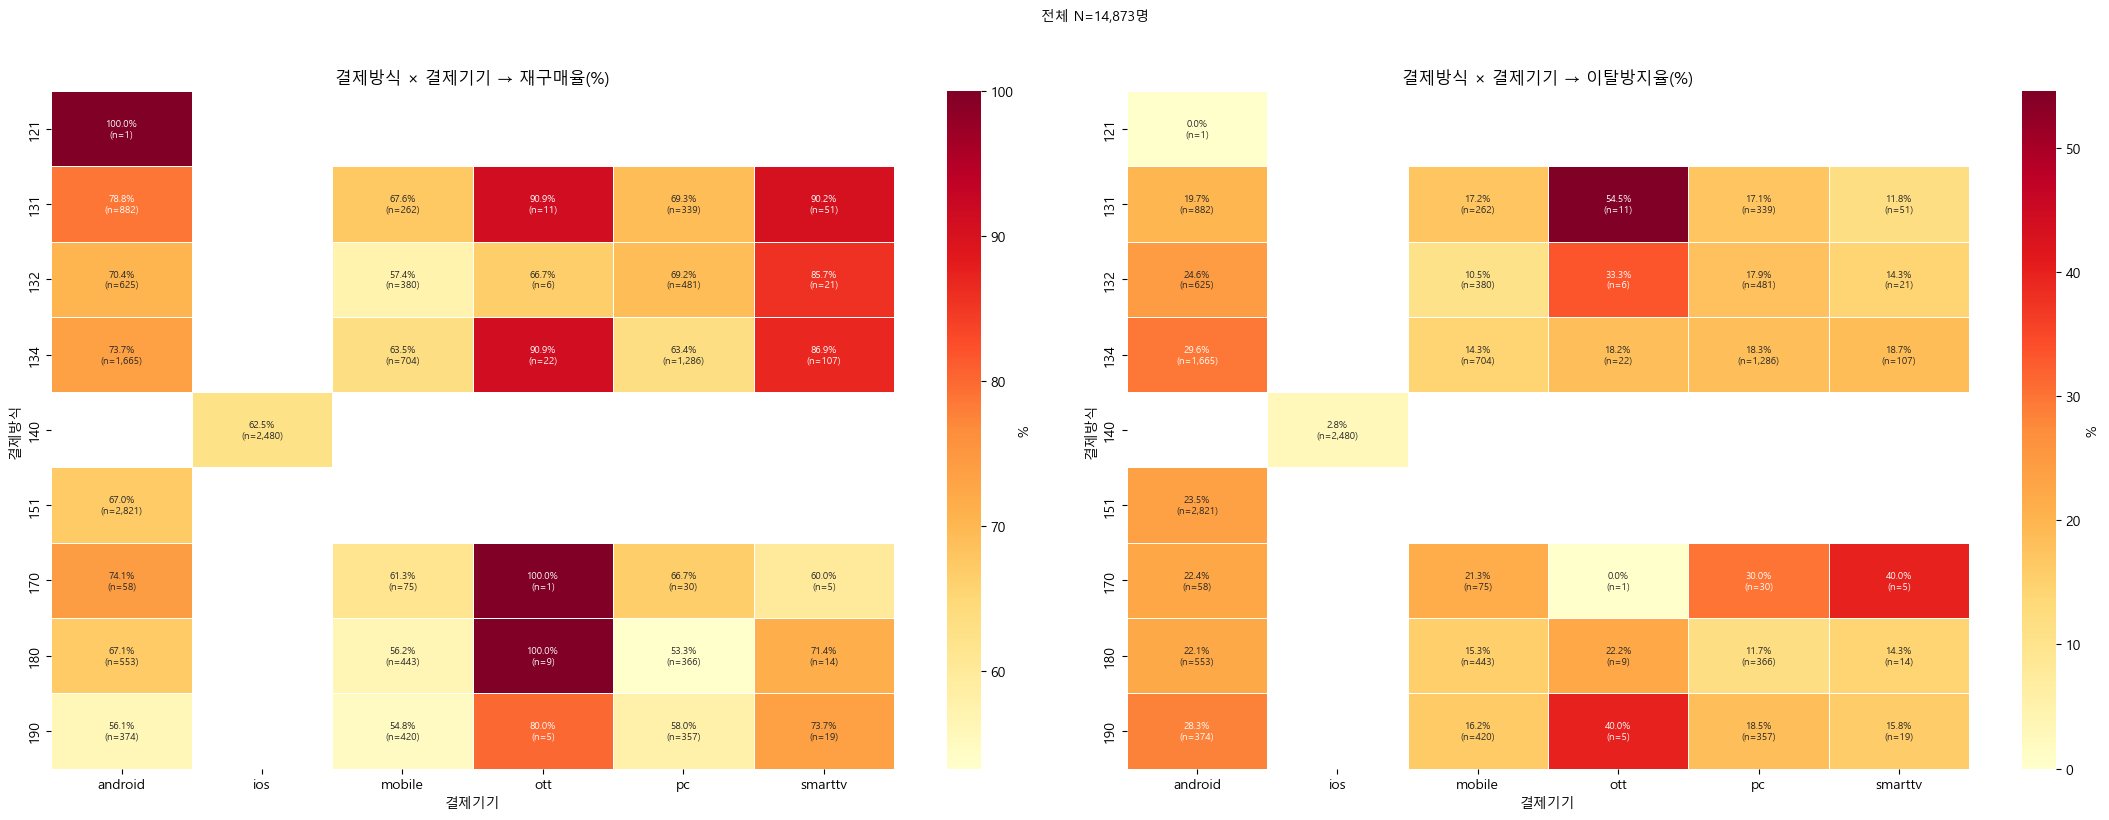

=== 결제방식 × 결제기기별 재구매율/이탈방지율 (%) ===
                               is_repurchase  is_churn_prevented
billing_method payment_device                                   
121            android                100.00                0.00
131            android                 78.80               19.73
               mobile                  67.56               17.18
               ott                     90.91               54.55
               pc                      69.32               17.11
               smarttv                 90.20               11.76
132            android                 70.40               24.64
               mobile                  57.37               10.53
               ott                     66.67               33.33
               pc                      69.23               17.88
               smarttv                 85.71               14.29
134            android                 73.69               29.61
               mobile                  63.49          

In [41]:
two_var_heatmap(df, 'billing_method', 'payment_device', '결제방식', '결제기기', figsize=(22, 8))

print('=== 결제방식 × 결제기기별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['billing_method', 'payment_device'])[OUTCOMES].mean().mul(100).round(2))
print('\n=== 결제방식 × 결제기기 샘플 수 ===')
print(df.groupby(['billing_method', 'payment_device']).size().unstack('payment_device').fillna(0).astype(int))

---
## 18. is_churn_prevented × gender → 재구매율 (역방향)
> 7~9번은 `재구매 → 이탈방지` 방향, 여기서는 반대 방향

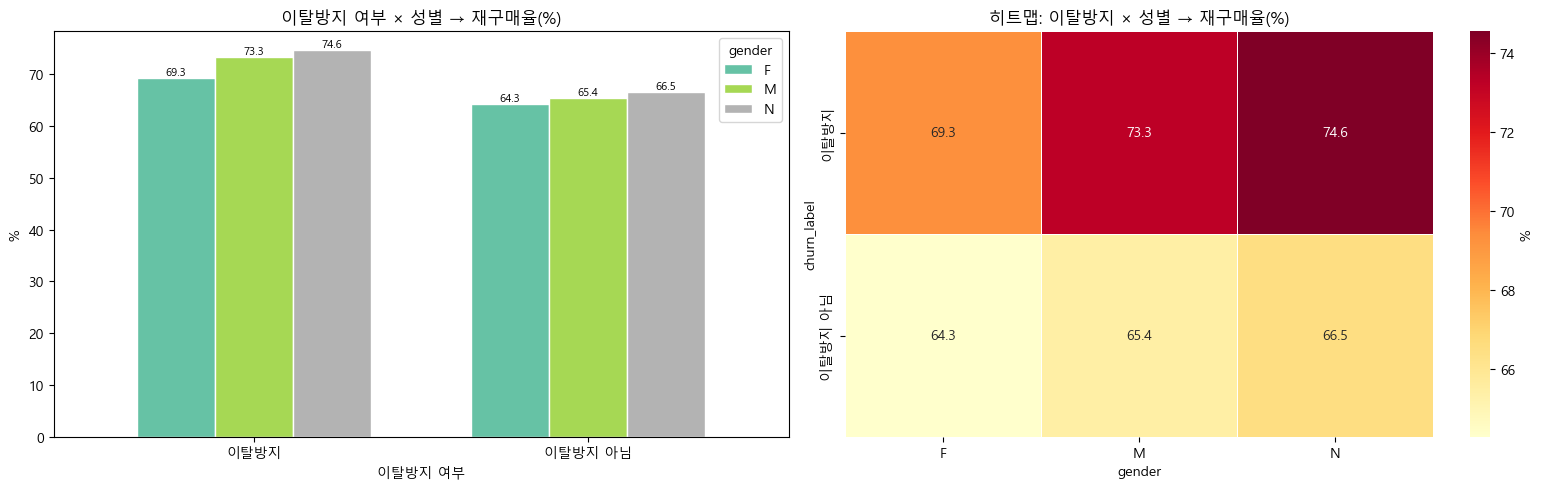

=== 이탈방지여부 × 성별별 재구매율 (%) ===
gender           F      M      N
churn_label                     
이탈방지         69.32  73.25  74.57
이탈방지 아님      64.27  65.43  66.51


In [42]:
pivot = df.groupby(['churn_label', 'gender'])['is_repurchase'].mean().mul(100).unstack('gender')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('이탈방지 여부 × 성별 → 재구매율(%)')
axes[0].set_xlabel('이탈방지 여부')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h):
        axes[0].annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                         ha='center', va='bottom', fontsize=8)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('히트맵: 이탈방지 × 성별 → 재구매율(%)')
plt.tight_layout()
plt.show()

print('=== 이탈방지여부 × 성별별 재구매율 (%) ===')
print(pivot.round(2))

---
## 19. is_churn_prevented × age_group → 재구매율 (역방향)

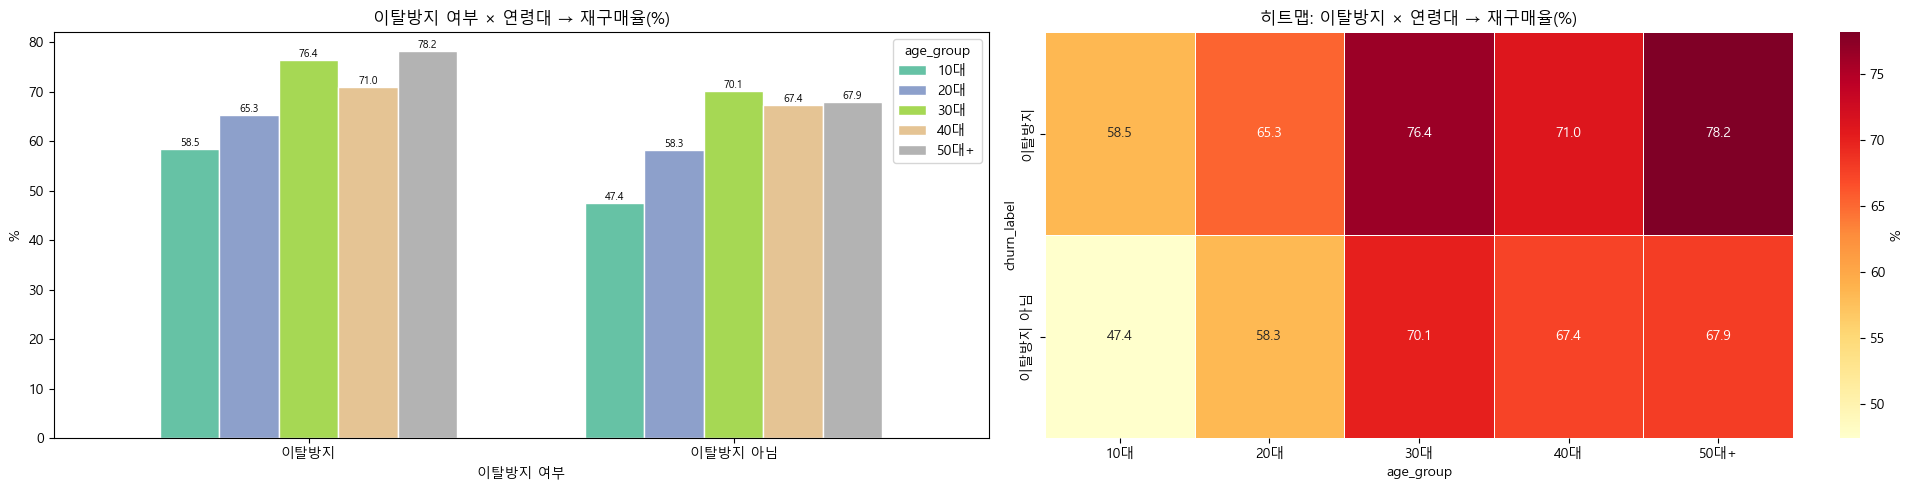

=== 이탈방지여부 × 연령대별 재구매율 (%) ===
age_group      10대    20대    30대    40대   50대+
churn_label                                   
이탈방지         58.46  65.28  76.41  71.00  78.18
이탈방지 아님      47.45  58.28  70.12  67.43  67.95


In [43]:
pivot = df.groupby(['churn_label', 'age_group'], observed=True)['is_repurchase'].mean().mul(100).unstack('age_group')

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('이탈방지 여부 × 연령대 → 재구매율(%)')
axes[0].set_xlabel('이탈방지 여부')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h):
        axes[0].annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                         ha='center', va='bottom', fontsize=7.5)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('히트맵: 이탈방지 × 연령대 → 재구매율(%)')
plt.tight_layout()
plt.show()

print('=== 이탈방지여부 × 연령대별 재구매율 (%) ===')
print(pivot.round(2))

---
## 20. is_churn_prevented × payment_device → 재구매율 (역방향)

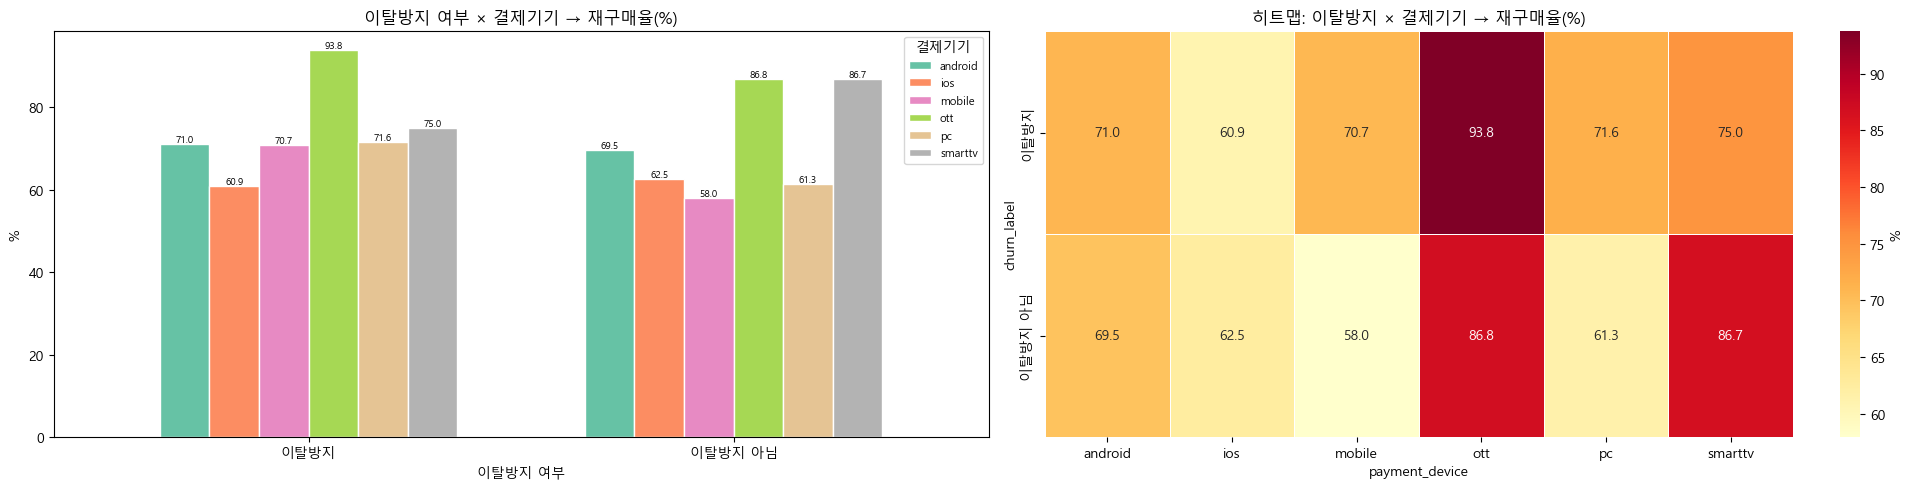

=== 이탈방지여부 × 결제기기별 재구매율 (%) ===
payment_device  android    ios  mobile    ott     pc  smarttv
churn_label                                                  
이탈방지              70.96  60.87   70.71  93.75  71.63    75.00
이탈방지 아님           69.53  62.51   57.97  86.84  61.35    86.74


In [44]:
pivot = df.groupby(['churn_label', 'payment_device'])['is_repurchase'].mean().mul(100).unstack('payment_device')

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('이탈방지 여부 × 결제기기 → 재구매율(%)')
axes[0].set_xlabel('이탈방지 여부')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='결제기기', fontsize=8)
for p in axes[0].patches:
    h = p.get_height()
    if not np.isnan(h):
        axes[0].annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                         ha='center', va='bottom', fontsize=7)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('히트맵: 이탈방지 × 결제기기 → 재구매율(%)')
plt.tight_layout()
plt.show()

print('=== 이탈방지여부 × 결제기기별 재구매율 (%) ===')
print(pivot.round(2))

---
## 21. duration_group × gender (구독기간 × 성별)
> 구독기간 = `end_date - reg_date` 로 계산한 파생 변수

=== 구독기간 분포 ===
duration_group
단기(<30일)         375
중기(30-89일)     14498
장기(90-364일)        0
초장기(1년+)           0
Name: count, dtype: int64


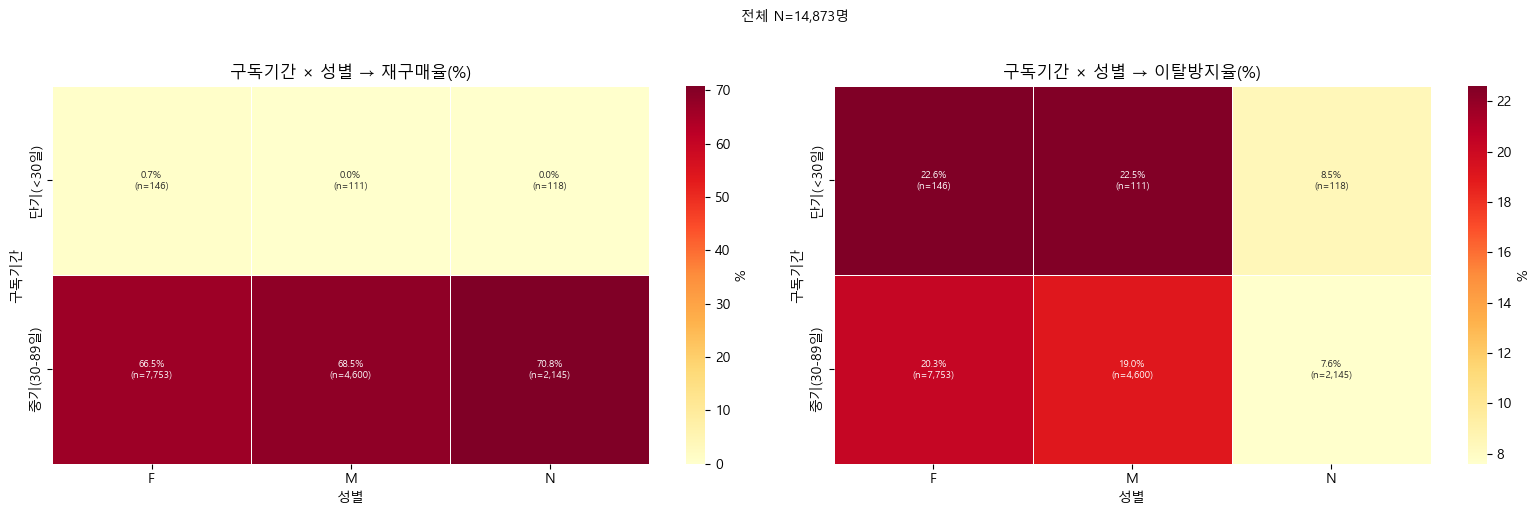

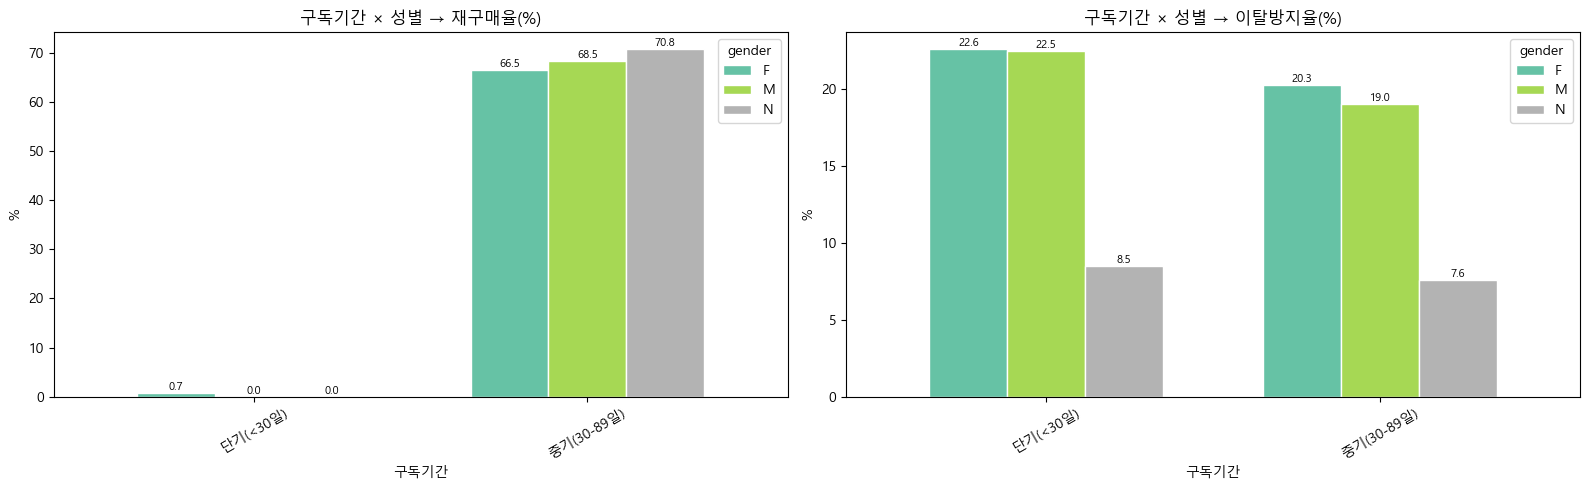

=== 구독기간 × 성별별 재구매율/이탈방지율 (%) ===
                       is_repurchase  is_churn_prevented
duration_group gender                                   
단기(<30일)       F                0.68               22.60
               M                0.00               22.52
               N                0.00                8.47
중기(30-89일)     F               66.52               20.30
               M               68.54               19.04
               N               70.82                7.60


In [45]:
print('=== 구독기간 분포 ===')
print(df['duration_group'].value_counts().sort_index())

two_var_heatmap(df, 'duration_group', 'gender', '구독기간', '성별', figsize=(16, 5))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, outcome in zip(axes, OUTCOMES):
    pivot = df.groupby(['duration_group', 'gender'], observed=True)[outcome].mean().mul(100).unstack('gender')
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
    ax.set_title(f'구독기간 × 성별 → {OUTCOME_LABELS[outcome]}')
    ax.set_xlabel('구독기간')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h):
            ax.annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('=== 구독기간 × 성별별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['duration_group', 'gender'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 22. duration_group × age_group (구독기간 × 연령대)

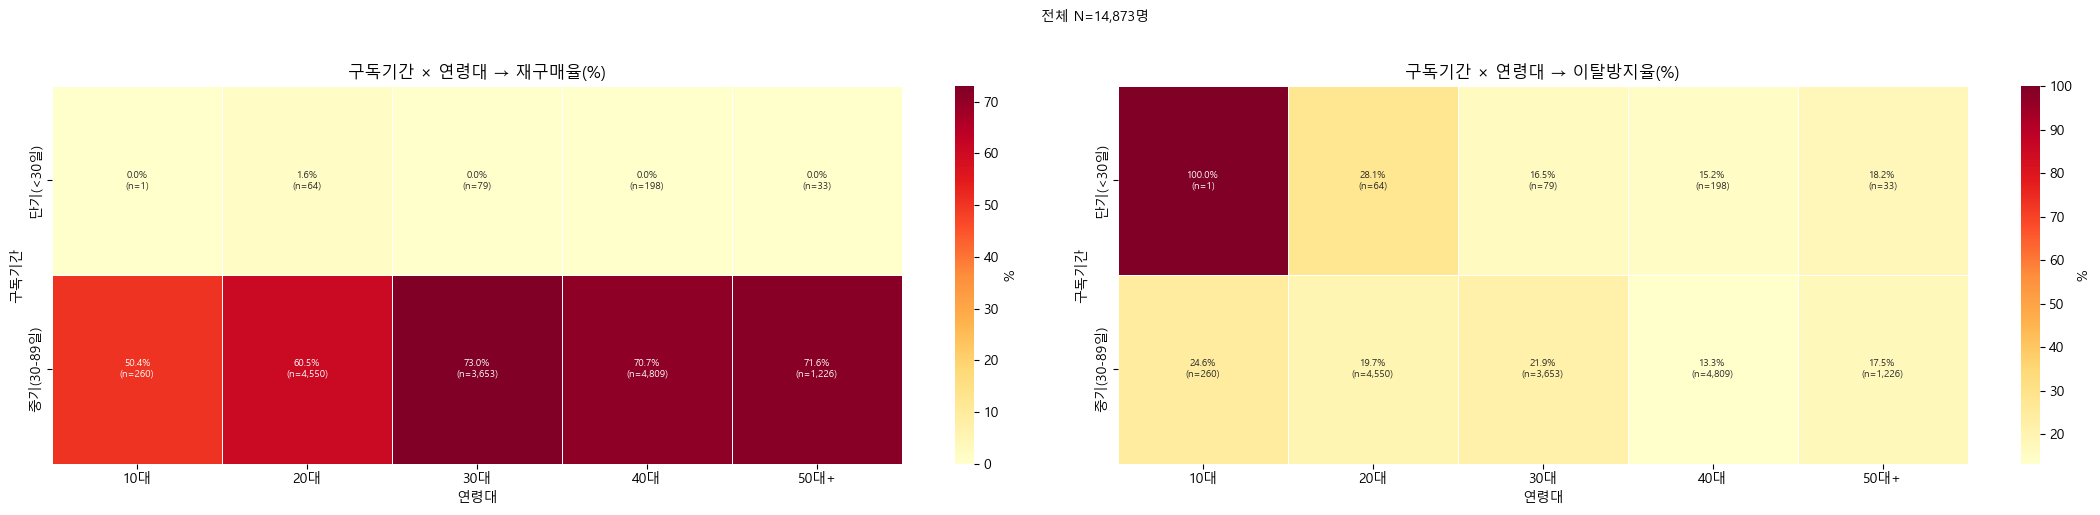

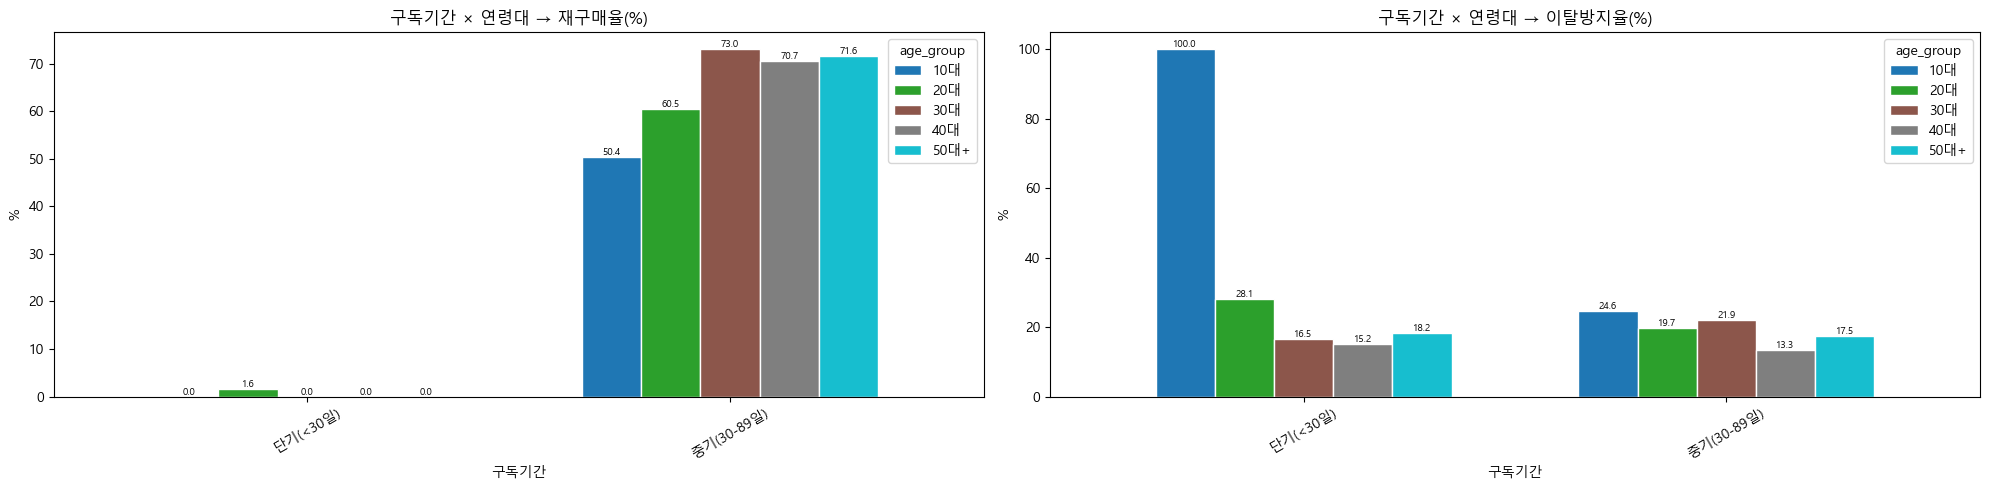

=== 구독기간 × 연령대별 재구매율/이탈방지율 (%) ===
                          is_repurchase  is_churn_prevented
duration_group age_group                                   
단기(<30일)       10대                 0.00              100.00
               20대                 1.56               28.12
               30대                 0.00               16.46
               40대                 0.00               15.15
               50대+                0.00               18.18
중기(30-89일)     10대                50.38               24.62
               20대                60.48               19.67
               30대                73.04               21.93
               40대                70.70               13.29
               50대+               71.62               17.46


In [46]:
two_var_heatmap(df, 'duration_group', 'age_group', '구독기간', '연령대', figsize=(22, 5))

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
for ax, outcome in zip(axes, OUTCOMES):
    pivot = df.groupby(['duration_group', 'age_group'], observed=True)[outcome].mean().mul(100).unstack('age_group')
    pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.7)
    ax.set_title(f'구독기간 × 연령대 → {OUTCOME_LABELS[outcome]}')
    ax.set_xlabel('구독기간')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h):
            ax.annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

print('=== 구독기간 × 연령대별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['duration_group', 'age_group'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 23. duration_group × is_100 (구독기간 × 100원딜)
> 100원딜 사용자와 일반 사용자의 구독기간 패턴 비교

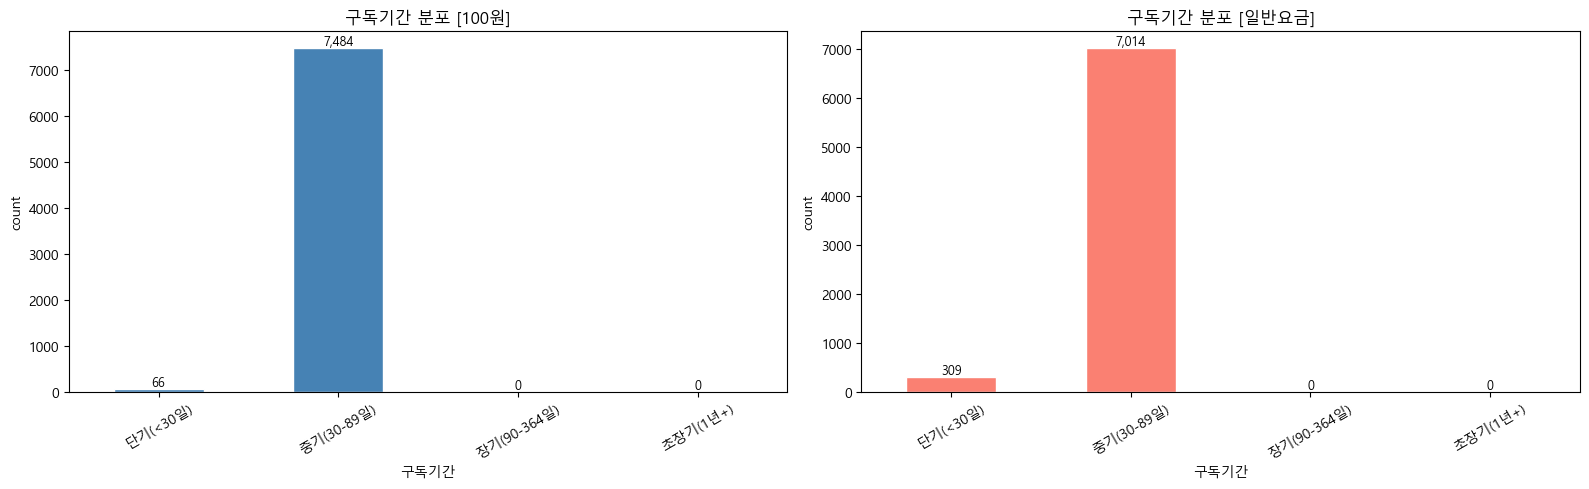

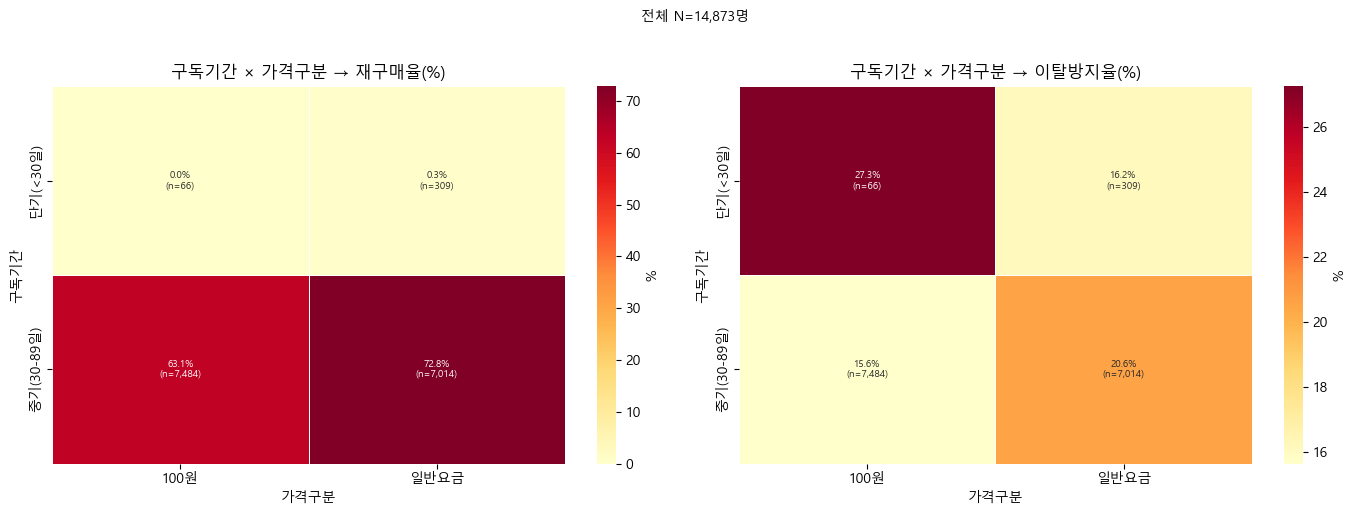

=== 구독기간(일) 기술통계: 100원 vs 일반요금 ===
              count  mean  std  min   25%   50%   75%   max
price_label                                                
100원         7550.0  30.7  2.8  0.0  31.0  31.0  31.0  31.0
일반요금         7323.0  30.1  6.1  0.0  31.0  31.0  32.0  32.0

=== 구독기간 × 100원딜별 재구매율/이탈방지율 (%) ===
                            is_repurchase  is_churn_prevented
duration_group price_label                                   
단기(<30일)       100원                  0.00               27.27
               일반요금                  0.32               16.18
중기(30-89일)     100원                 63.07               15.65
               일반요금                 72.84               20.56


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', df[df['is_100']==1]), ('일반요금', df[df['is_100']==0])]):
    cnt = sub['duration_group'].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label == '100원' else 'salmon', edgecolor='white')
    ax.set_title(f'구독기간 분포 [{label}]')
    ax.set_xlabel('구독기간')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

two_var_heatmap(df, 'duration_group', 'price_label', '구독기간', '가격구분', figsize=(14, 5))

print('=== 구독기간(일) 기술통계: 100원 vs 일반요금 ===')
print(df.groupby('price_label')['duration_days'].describe().round(1))

print('\n=== 구독기간 × 100원딜별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['duration_group', 'price_label'], observed=True)[OUTCOMES].mean().mul(100).round(2))

---
## 24. 3-way: is_100 × gender × age_group → 재구매율/이탈방지율
> 3변수 교호작용: 100원딜 여부 + 성별 + 연령대가 결합될 때 어떻게 달라지는가

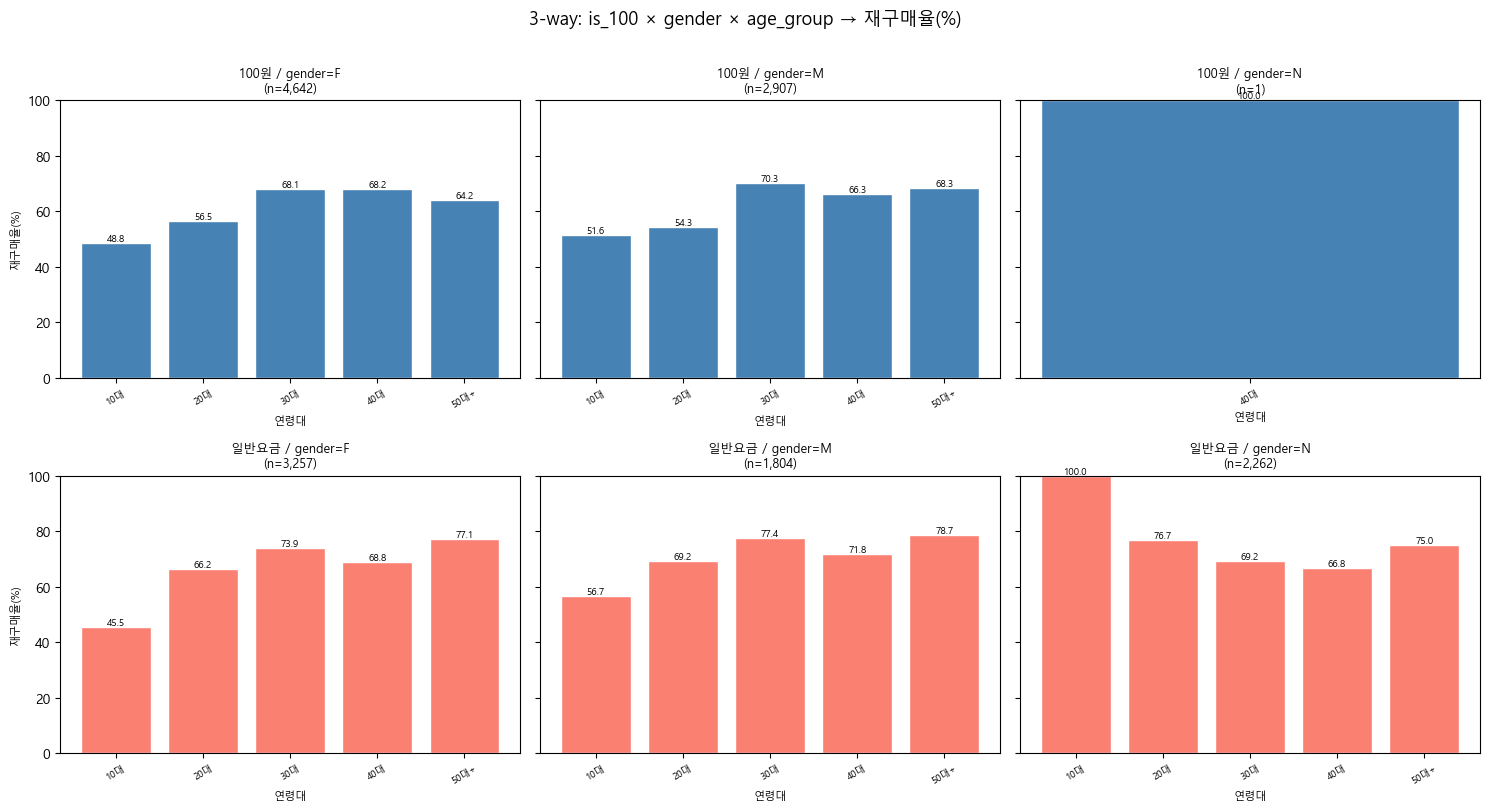

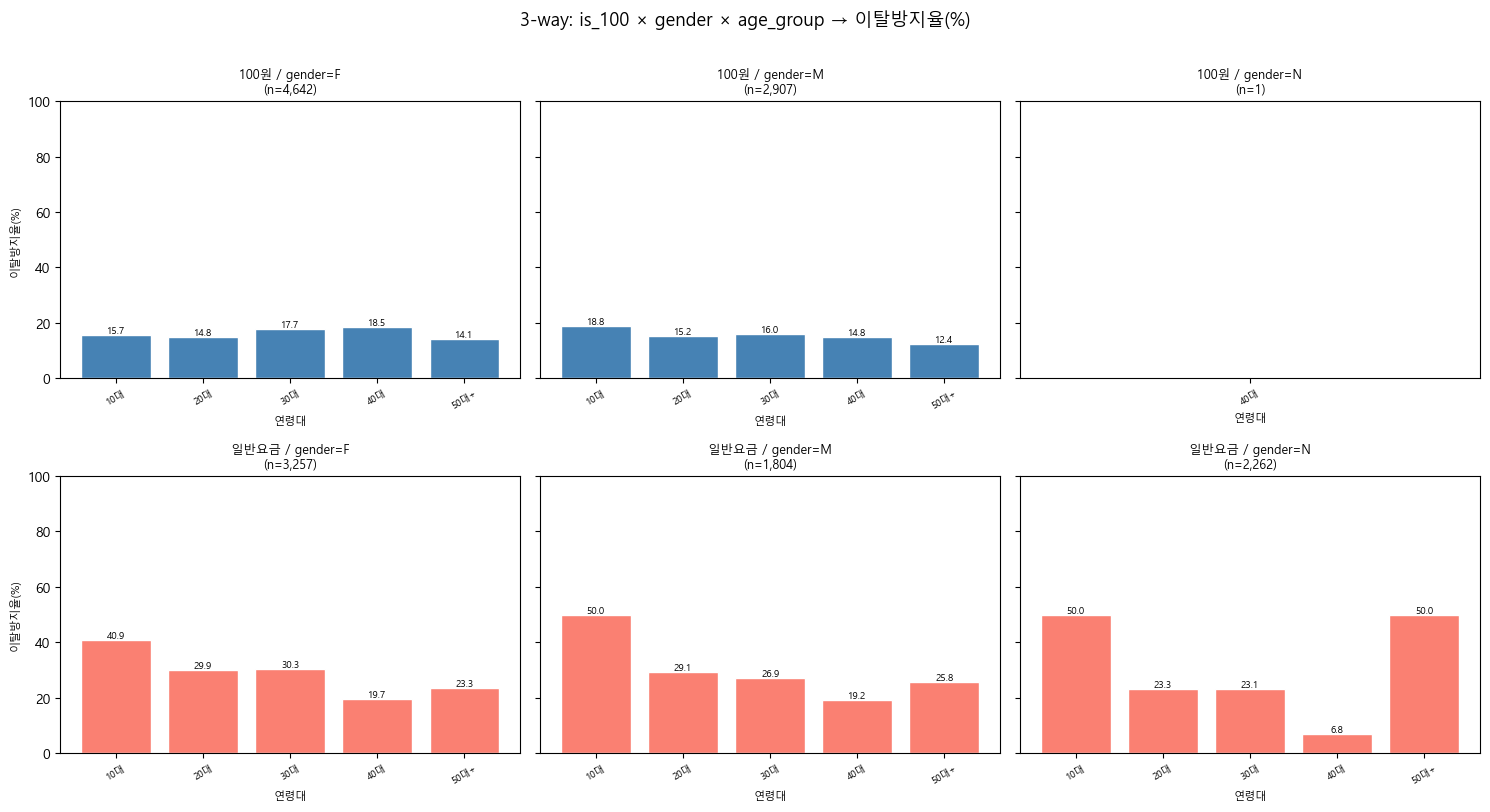

=== 3-way 수치표: is_100 × gender × age_group (%) ===
                              is_repurchase  is_churn_prevented
price_label gender age_group                                   
100원        F      10대                48.76               15.70
                   20대                56.49               14.76
                   30대                68.07               17.65
                   40대                68.19               18.53
                   50대+               64.24               14.15
            M      10대                51.56               18.75
                   20대                54.35               15.19
                   30대                70.31               16.05
                   40대                66.28               14.84
                   50대+               68.25               12.38
            N      40대               100.00                0.00
일반요금        F      10대                45.45               40.91
                   20대                66.24          

In [48]:
genders = sorted(df['gender'].dropna().unique())
price_labels = ['100원', '일반요금']

for outcome in OUTCOMES:
    fig, axes = plt.subplots(len(price_labels), len(genders),
                             figsize=(5 * len(genders), 8), sharey=True)
    for i, price in enumerate(price_labels):
        for j, gender in enumerate(genders):
            ax = axes[i][j]
            sub = df[(df['price_label'] == price) & (df['gender'] == gender)]
            vals = sub.groupby('age_group', observed=True)[outcome].mean().mul(100)
            color = 'steelblue' if price == '100원' else 'salmon'
            bars = ax.bar(vals.index.astype(str), vals.values, color=color, edgecolor='white')
            ax.set_title(f'{price} / gender={gender}\n(n={len(sub):,})', fontsize=9)
            ax.set_ylim(0, 100)
            ax.set_xlabel('연령대', fontsize=8)
            if j == 0:
                ax.set_ylabel(OUTCOME_LABELS[outcome], fontsize=8)
            ax.tick_params(axis='x', rotation=30, labelsize=7)
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h) and h > 0:
                    ax.annotate(f'{h:.1f}', (bar.get_x() + bar.get_width()/2, h),
                                ha='center', va='bottom', fontsize=7)
    fig.suptitle(f'3-way: is_100 × gender × age_group → {OUTCOME_LABELS[outcome]}',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

print('=== 3-way 수치표: is_100 × gender × age_group (%) ===')
print(df.groupby(['price_label', 'gender', 'age_group'], observed=True)[OUTCOMES].mean().mul(100).round(2).to_string())

---
## 25. 3-way: is_100 × age_group × payment_device → 재구매율/이탈방지율

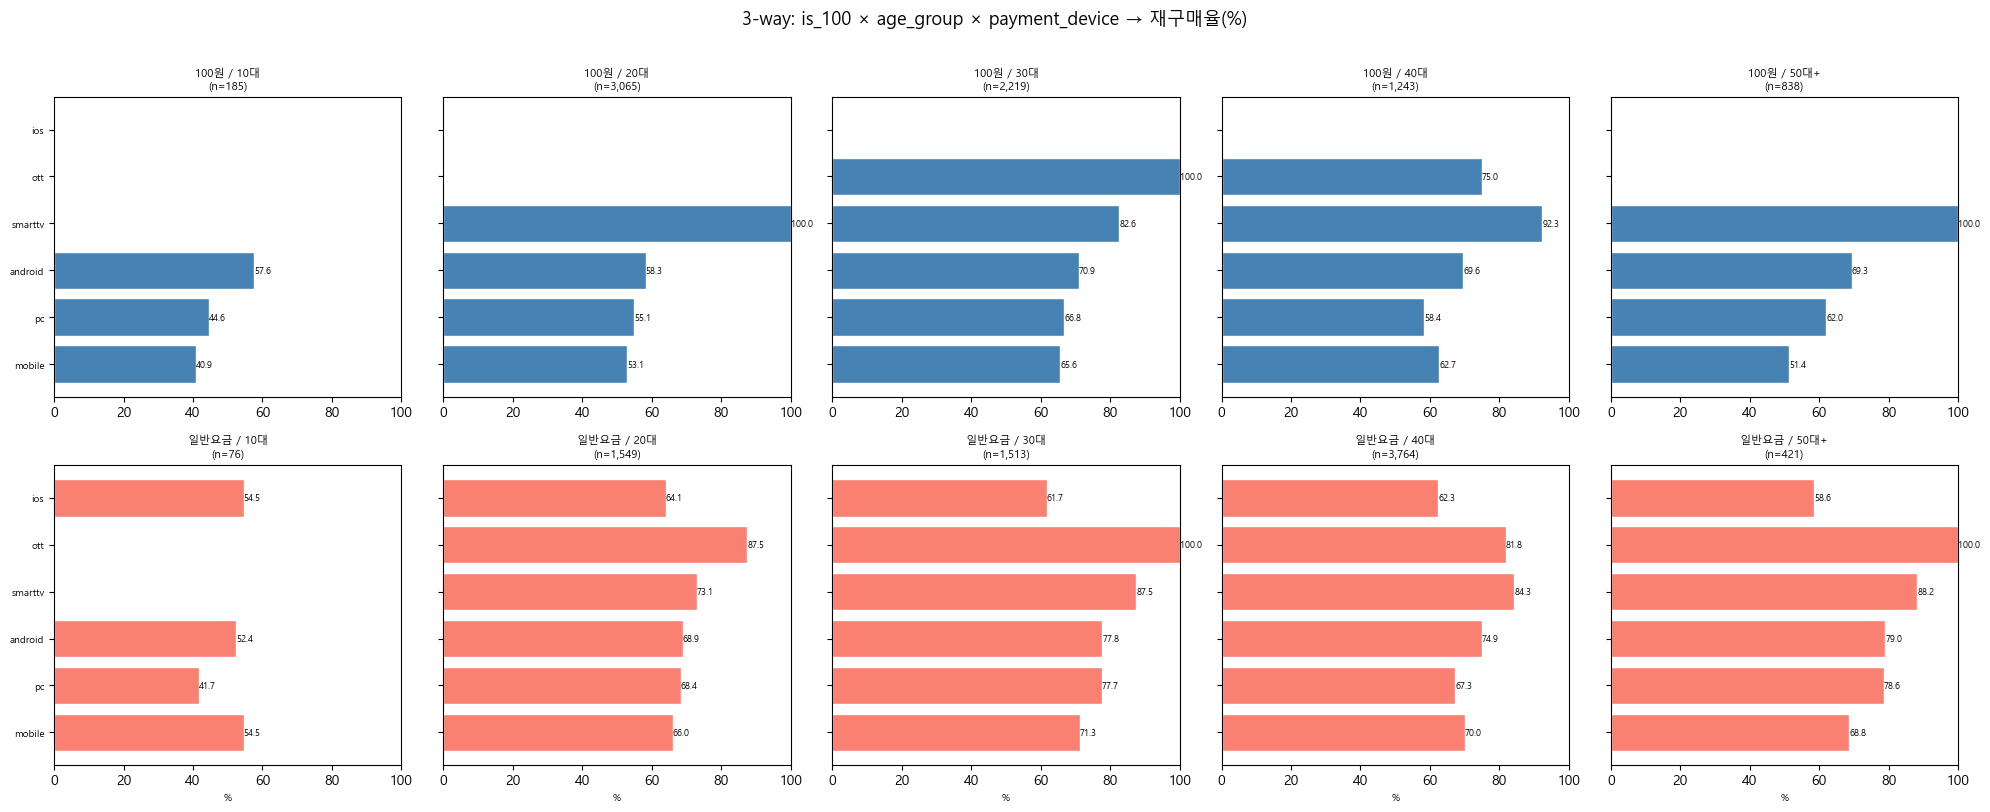

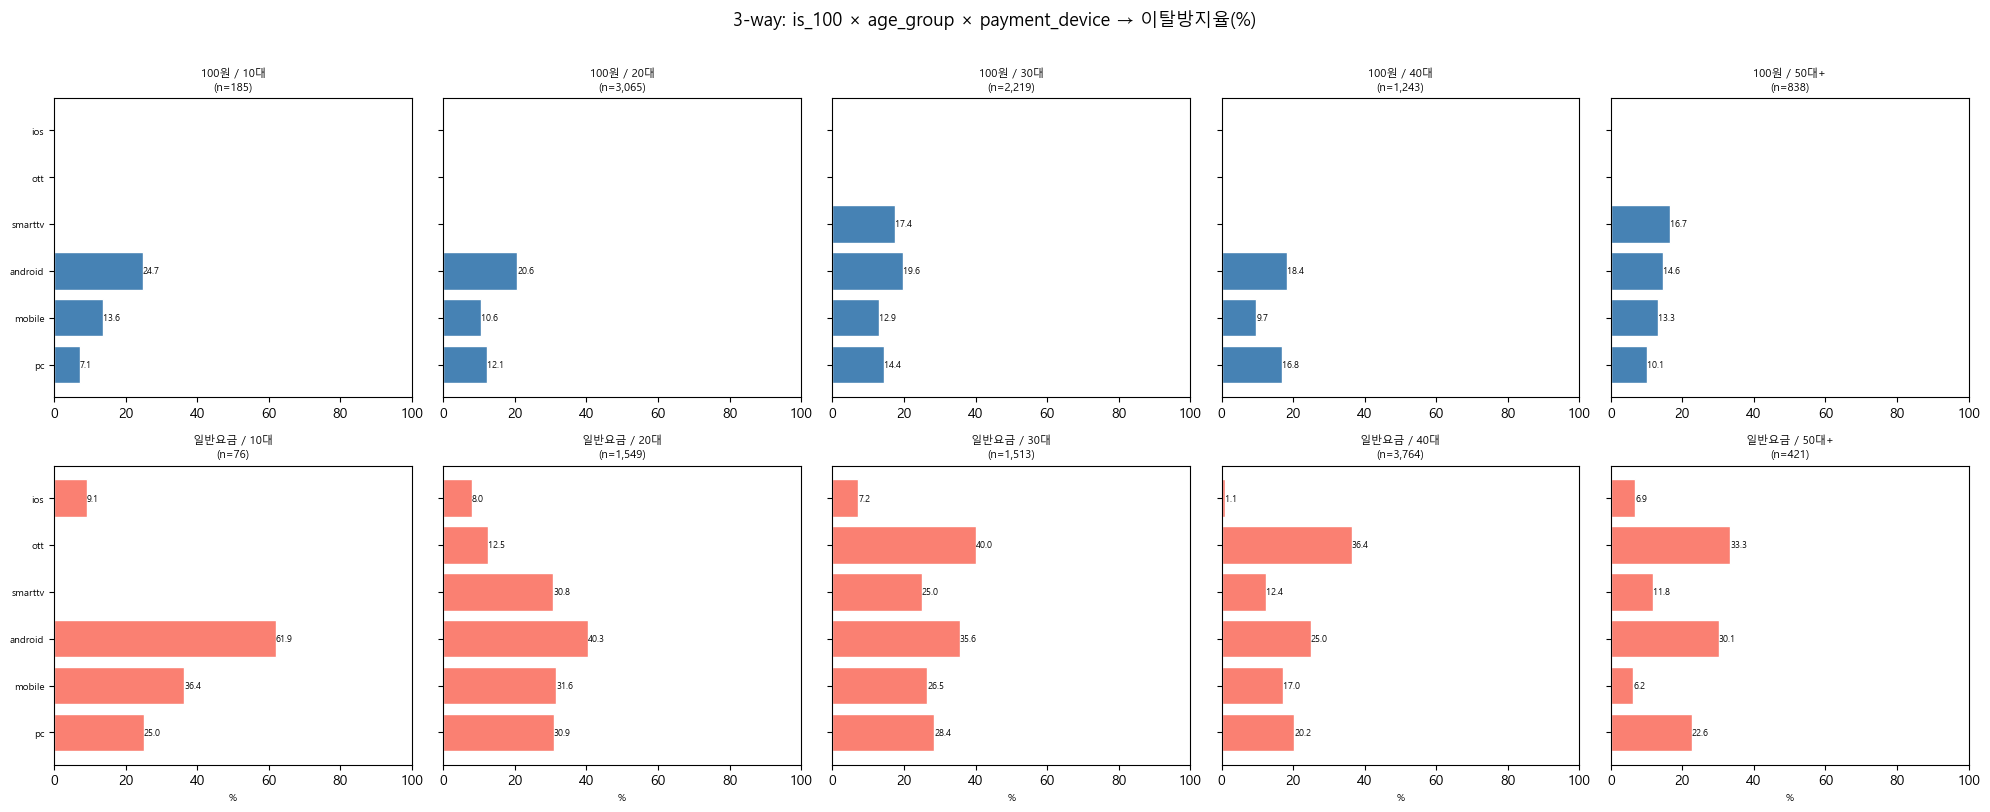

=== 3-way 수치표: is_100 × age_group × payment_device (%) ===
                                      is_repurchase  is_churn_prevented
price_label age_group payment_device                                   
100원        10대       android                 57.65               24.71
                      mobile                  40.91               13.64
                      pc                      44.64                7.14
            20대       android                 58.31               20.63
                      mobile                  53.05               10.63
                      pc                      55.06               12.14
                      smarttv                100.00                0.00
            30대       android                 70.89               19.62
                      mobile                  65.57               12.94
                      ott                    100.00                0.00
                      pc                      66.80               14.37
     

In [49]:
age_groups = df['age_group'].cat.categories.tolist()

for outcome in OUTCOMES:
    fig, axes = plt.subplots(len(price_labels), len(age_groups),
                             figsize=(4 * len(age_groups), 8), sharey=True)
    for i, price in enumerate(price_labels):
        for j, age in enumerate(age_groups):
            ax = axes[i][j]
            sub = df[(df['price_label'] == price) & (df['age_group'] == age)]
            vals = sub.groupby('payment_device')[outcome].mean().mul(100).sort_values()
            color = 'steelblue' if price == '100원' else 'salmon'
            bars = ax.barh(vals.index.astype(str), vals.values, color=color, edgecolor='white')
            ax.set_title(f'{price} / {age}\n(n={len(sub):,})', fontsize=8)
            ax.set_xlim(0, 100)
            if i == len(price_labels) - 1:
                ax.set_xlabel('%', fontsize=7)
            ax.tick_params(axis='y', labelsize=7)
            for bar in bars:
                w = bar.get_width()
                if not np.isnan(w) and w > 0:
                    ax.annotate(f'{w:.1f}', (w, bar.get_y() + bar.get_height()/2),
                                ha='left', va='center', fontsize=6.5)
    fig.suptitle(f'3-way: is_100 × age_group × payment_device → {OUTCOME_LABELS[outcome]}',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

print('=== 3-way 수치표: is_100 × age_group × payment_device (%) ===')
print(df.groupby(['price_label', 'age_group', 'payment_device'], observed=True)[OUTCOMES].mean().mul(100).round(2).to_string())

---
## 26. 종합 요약: 전체 교호작용 효과 크기 비교
> 각 변수 조합의 효과 범위(max - min)를 비교해 어떤 교호작용이 가장 강한지 확인


===== 재구매율(%) — 교호작용 효과 크기 순위 =====
                   최소값(%)  최대값(%)  효과범위(max-min)   표준편차
교호작용                                                   
상품코드 × 성별            0.00  100.00         100.00  30.52
재구매 × 성별 → 이탈방지      0.00  100.00         100.00  54.77
재구매 × 연령대 → 이탈방지     0.00  100.00         100.00  52.70
재구매 × 결제기기 → 이탈방지    0.00  100.00         100.00  52.22
상품코드 × 연령대           0.00  100.00         100.00  31.01
구독기간 × 연령대           0.00   73.04          73.04  34.83
구독기간 × 100원딜         0.00   72.84          72.84  39.34
구독기간 × 성별            0.00   70.82          70.82  37.49
연령대 × 결제방식          38.89  100.00          61.11  12.67
연령대 × 결제기기          43.64  100.00          56.36  14.94
성별 × 연령대            47.88  100.00          52.12  11.86
결제방식 × 결제기기         53.28  100.00          46.72  13.83
결제방식 × 성별           54.85  100.00          45.15   9.84
연령대 × 동시접속수         41.94   81.42          39.48  11.43
성별 × 결제기기           58.55   95.24          36.69  11.16
이탈방지 × 결제기기

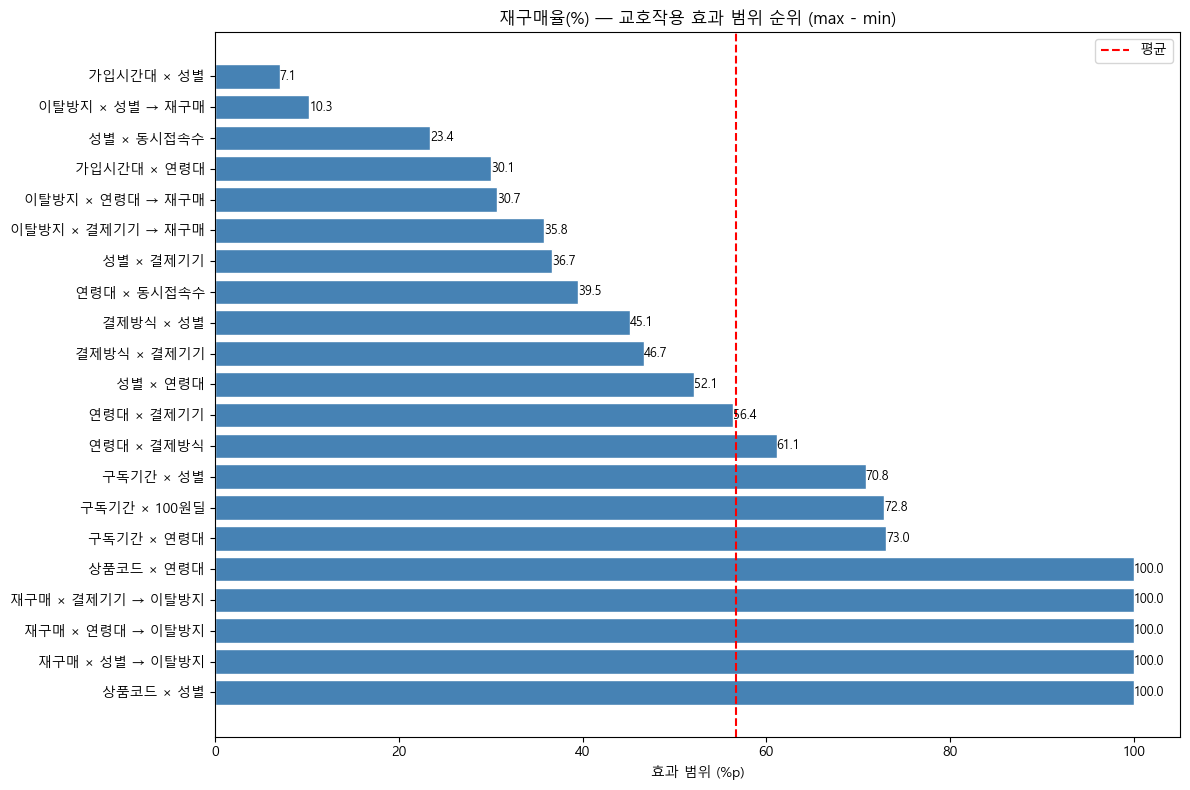


===== 이탈방지율(%) — 교호작용 효과 크기 순위 =====
                   최소값(%)  최대값(%)  효과범위(max-min)   표준편차
교호작용                                                   
상품코드 × 성별            0.00  100.00         100.00  16.60
이탈방지 × 결제기기 → 재구매    0.00  100.00         100.00  52.22
이탈방지 × 연령대 → 재구매     0.00  100.00         100.00  52.70
이탈방지 × 성별 → 재구매      0.00  100.00         100.00  54.77
상품코드 × 연령대           0.00  100.00         100.00  16.63
구독기간 × 연령대          13.29  100.00          86.71  25.87
결제방식 × 결제기기          0.00   54.55          54.55  11.16
연령대 × 결제방식           0.00   50.00          50.00   9.69
성별 × 연령대             6.80   50.00          43.20  11.63
성별 × 결제기기            0.75   38.10          37.35   9.14
연령대 × 결제기기           1.09   37.01          35.92   9.22
가입시간대 × 연령대         11.44   41.51          30.07   6.50
재구매 × 결제기기 → 이탈방지    2.71   31.25          28.54   8.99
결제방식 × 성별            0.00   26.61          26.61   7.34
가입시간대 × 성별           6.75   24.26          17.50   6.49
재구매 × 연령대 

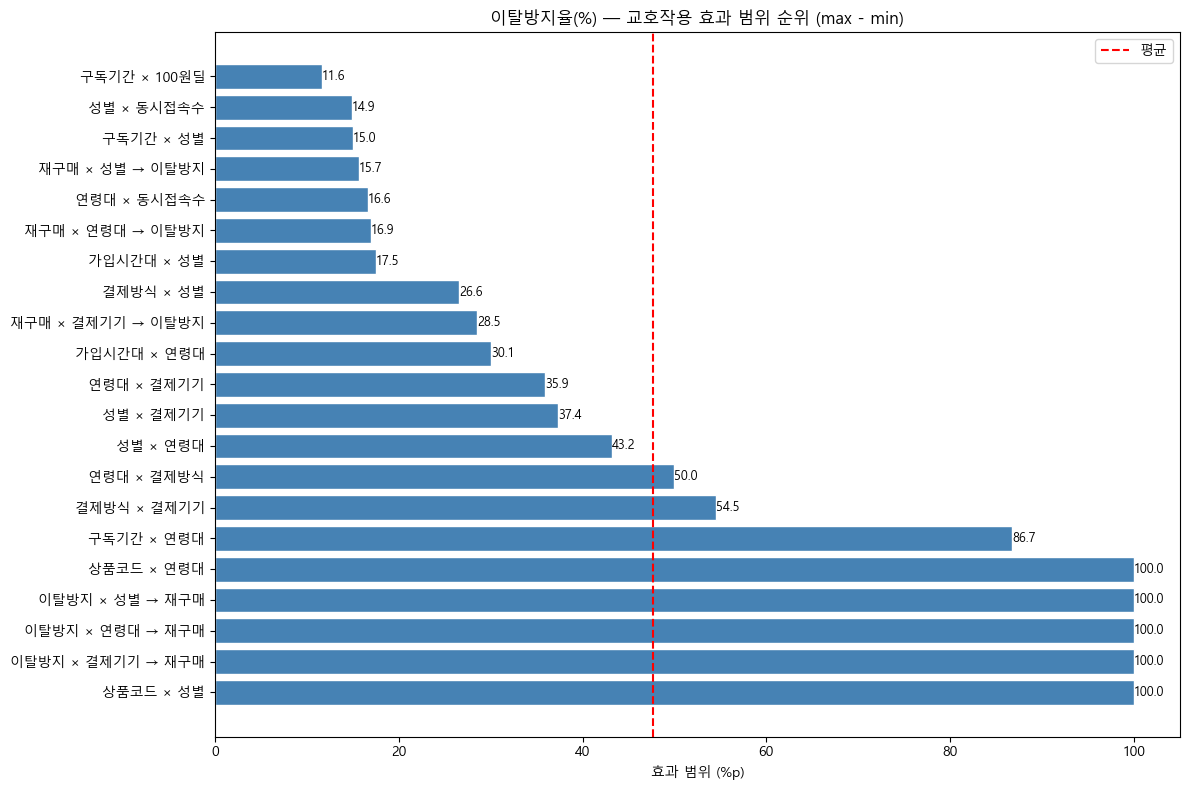

In [50]:
all_pairs = [
    # 기본 교호작용
    ('gender',          'age_group',        '성별 × 연령대'),
    ('gender',          'payment_device',   '성별 × 결제기기'),
    ('gender',          'max_screen',       '성별 × 동시접속수'),
    ('age_group',       'payment_device',   '연령대 × 결제기기'),
    ('age_group',       'max_screen',       '연령대 × 동시접속수'),
    ('age_group',       'billing_method',   '연령대 × 결제방식'),
    ('repurchase_label','gender',           '재구매 × 성별 → 이탈방지'),
    ('repurchase_label','age_group',        '재구매 × 연령대 → 이탈방지'),
    ('repurchase_label','payment_device',   '재구매 × 결제기기 → 이탈방지'),
    # 심화 교호작용
    ('reg_hour_group',  'gender',           '가입시간대 × 성별'),
    ('reg_hour_group',  'age_group',        '가입시간대 × 연령대'),
    ('product_code',    'gender',           '상품코드 × 성별'),
    ('product_code',    'age_group',        '상품코드 × 연령대'),
    ('billing_method',  'gender',           '결제방식 × 성별'),
    ('billing_method',  'payment_device',   '결제방식 × 결제기기'),
    ('churn_label',     'gender',           '이탈방지 × 성별 → 재구매'),
    ('churn_label',     'age_group',        '이탈방지 × 연령대 → 재구매'),
    ('churn_label',     'payment_device',   '이탈방지 × 결제기기 → 재구매'),
    ('duration_group',  'gender',           '구독기간 × 성별'),
    ('duration_group',  'age_group',        '구독기간 × 연령대'),
    ('duration_group',  'price_label',      '구독기간 × 100원딜'),
]

for outcome in OUTCOMES:
    rows = []
    for r_col, c_col, label in all_pairs:
        try:
            vals = df.groupby([r_col, c_col], observed=True)[outcome].mean().mul(100).dropna()
            rows.append({
                '교호작용': label,
                '최소값(%)': round(vals.min(), 2),
                '최대값(%)': round(vals.max(), 2),
                '효과범위(max-min)': round(vals.max() - vals.min(), 2),
                '표준편차': round(vals.std(), 2)
            })
        except Exception:
            pass
    summary = pd.DataFrame(rows).set_index('교호작용').sort_values('효과범위(max-min)', ascending=False)
    print(f'\n===== {OUTCOME_LABELS[outcome]} — 교호작용 효과 크기 순위 =====')
    print(summary.to_string())

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(summary.index, summary['효과범위(max-min)'], color='steelblue', edgecolor='white')
    ax.set_title(f'{OUTCOME_LABELS[outcome]} — 교호작용 효과 범위 순위 (max - min)')
    ax.set_xlabel('효과 범위 (%p)')
    ax.axvline(summary['효과범위(max-min)'].mean(), color='red', linestyle='--', label='평균')
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}', (p.get_width(), p.get_y() + p.get_height()/2),
                    ha='left', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()